In [1]:
from MieSppForce.simulation import SimulationConfig, SweepRunner,  DipoleCalculator, OpticalForceCalculator, CylindricalGrid
import matplotlib.pyplot as plt
import numpy as np
from pint import UnitRegistry
ureg = UnitRegistry()

from numpy import pi, sin,cos,exp

one_beam_base_config = SimulationConfig(
    wl = 900 * ureg.nanometer,
    R =  (295/2) * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(25),
    psi= np.pi/2,
    chi= np.pi/4,
    show_warnings=False,
    initial_field_type='plane_wave'
)

two_beam_base_config = SimulationConfig(
    wl = 900 * ureg.nanometer,
    R =  (295/2) * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(25),
    psi = np.pi/2,
    chi= np.pi/4,
    show_warnings=False,
    initial_field_type='two_beam'
)

/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
gridCylXoY_reg = CylindricalGrid(one_beam_base_config.wl, 
                       np.linspace(0,2*np.pi,100)*ureg.rad, 
                       one_beam_base_config.R + one_beam_base_config.dist)

one_sweep_res, one_diagrams_spp, _ = SweepRunner(one_beam_base_config, 'R', np.linspace(100, 165, 100)*ureg.nanometer, True, True, True, False, None, 'spp').run(n_jobs=-1)

two_sweep_res, two_diagrams_spp, _ = SweepRunner(two_beam_base_config, 'R', np.linspace(100, 165, 100)*ureg.nanometer, True, True, True, False, None, 'spp').run(n_jobs=-1)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [3]:
#Free Space

base_config_free_space = SimulationConfig(
    wl = 900 * ureg.nanometer,
    R =  (295/2) * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(0),
    psi = 0,
    chi= 0,
    substrate='Air',
    initial_field_type='plane_wave',
    show_warnings=False
)

sweep_res_free_space, _, _ = SweepRunner(base_config_free_space, 'R', np.linspace(100, 165, 100)*ureg.nanometer, True, False, True, False).run()

F0 = np.max(np.abs(sweep_res_free_space.Fz))

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]


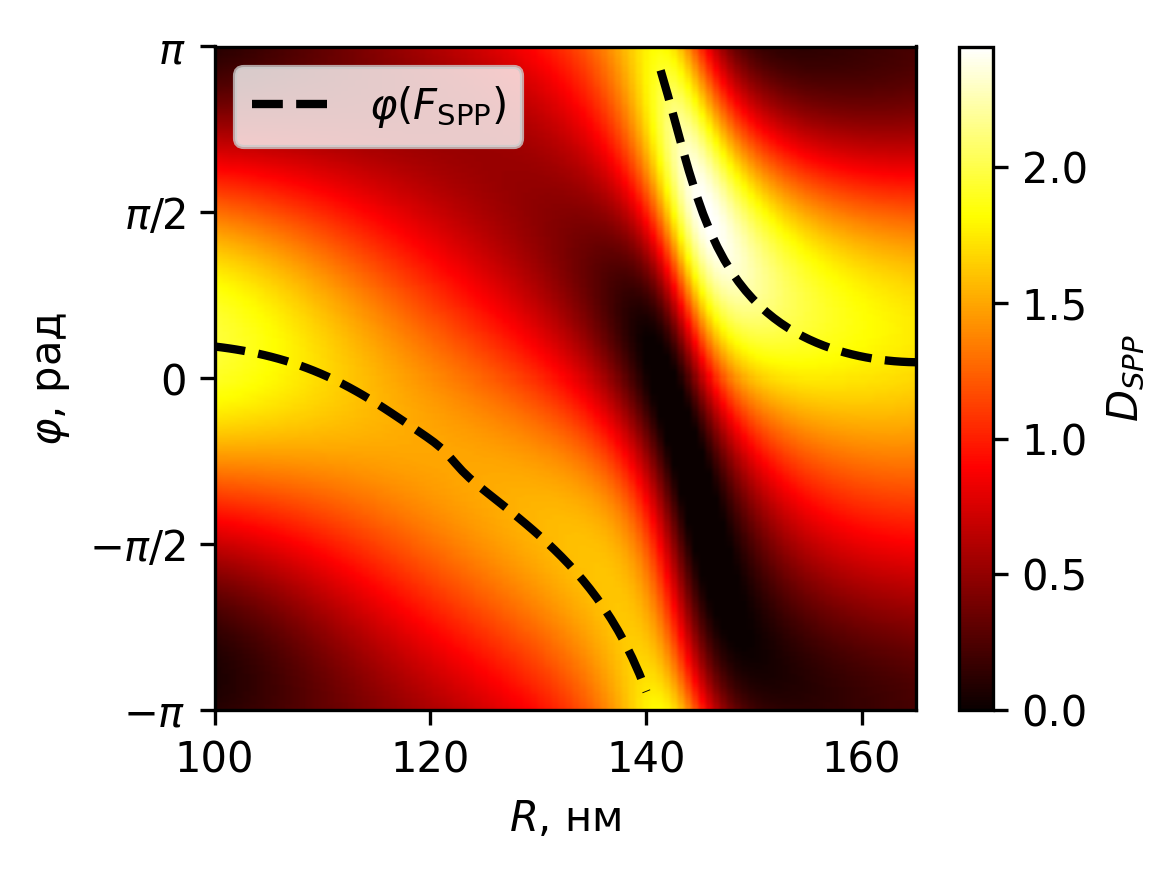

In [4]:
one_diagrams_spp["phi"] = one_diagrams_spp["phi"].apply(lambda x: x.magnitude if hasattr(x, "magnitude") else x)
one_diagrams_spp["R"]  = one_diagrams_spp["R"].apply(lambda x: x.magnitude if hasattr(x, "magnitude") else x)

pivot = one_diagrams_spp.pivot(index="phi", columns="R", values="D")

# Shift phi from [0, 2π] to [-π, π] and reindex/sort for correct display
phi_vals = pivot.index.values.astype(float)
phi_shift = np.where(phi_vals > np.pi, phi_vals - 2*np.pi, phi_vals)
pivot.index = phi_shift
pivot = pivot.sort_index()

plt.figure(figsize=(4, 3), dpi=300)

# image: x -> R, y -> phi (now in [-π, π])
plt.imshow(
    pivot.values.astype(float),
    aspect="auto",
    origin="lower",
    extent=[
        float(pivot.columns.min()), float(pivot.columns.max()),
        float(pivot.index.min()),   float(pivot.index.max())
    ],
    cmap="hot",
    vmin=0,
    )
    
    

phi_spp = np.arctan2(one_sweep_res.Fyspp.magnitude, one_sweep_res.Fxspp.magnitude) + np.pi
phi_spp_plot = np.asarray([i-np.pi*2 if i >np.pi else i for i in phi_spp])
dphi = np.abs(np.diff(phi_spp_plot))
breaks = np.where(dphi > np.pi)[0]
for idx in breaks:
    phi_spp_plot[idx + 1] = np.nan
    

# Plot gold dashed line with thin black outline
# import matplotlib.patheffects as pe
# plt.plot(one_sweep_res.R.magnitude, phi_spp_plot, label="$\\varphi(F_{\\text{ППП}})$",
#          color='gold', ls='--', linewidth=2,
#          path_effects=[pe.Stroke(linewidth=4, foreground='black'), pe.Normal()])
plt.plot(one_sweep_res.R.magnitude, phi_spp_plot, label="$\\varphi(F_{\\text{SPP}})$",
         color='black', ls='--', linewidth=2)

plt.colorbar(label="$D_{SPP}$")
plt.xlabel("$R$, нм")
plt.ylabel("$\\varphi$, рад")

yticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
yticklabels = ["$-\\pi$", "$-\\pi/2$", "$0$", "$\\pi/2$", "$\\pi$"]

plt.yticks(yticks, yticklabels)
plt.ylim(-np.pi, np.pi)
plt.tight_layout()
plt.legend()
#plt.savefig('proceeding/Dspp_vs_F_map_R.png', dpi=300)
plt.show()

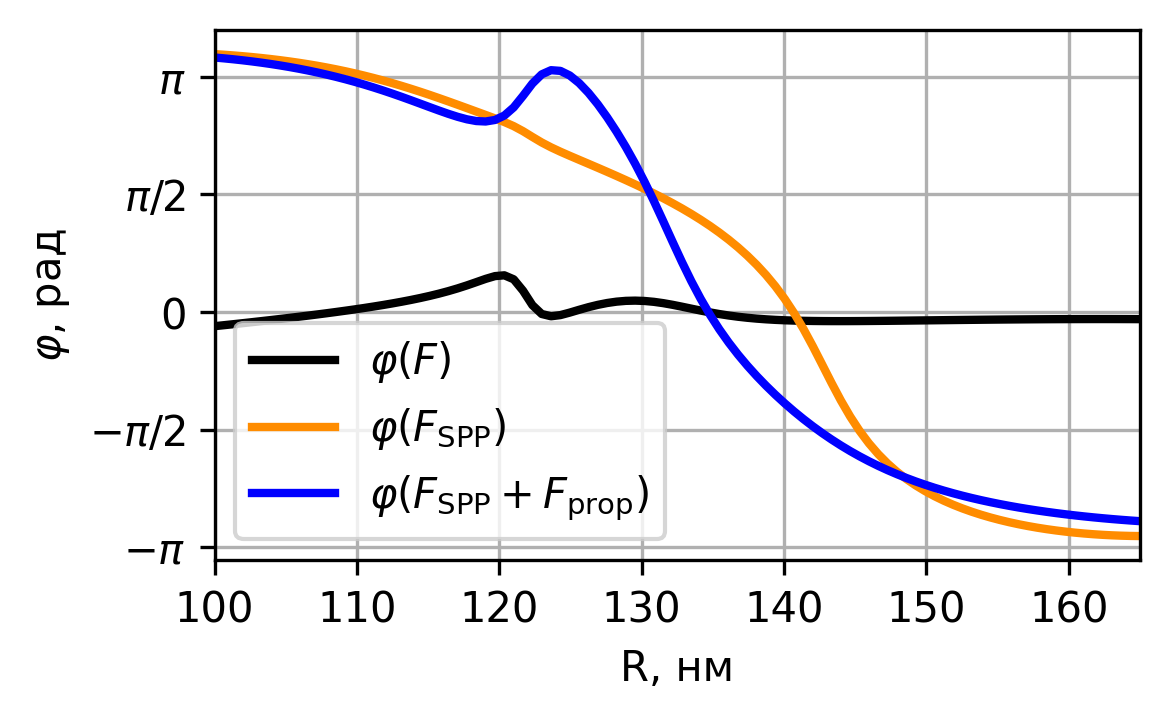

In [5]:
Fx_no_sc = one_sweep_res.Fx.magnitude - one_sweep_res.Fxe0.magnitude - one_sweep_res.Fxm0.magnitude


plt.figure(figsize=(4, 2.5), dpi=300)
plt.plot(one_sweep_res.R, np.unwrap(np.arctan2(one_sweep_res.Fy.magnitude, one_sweep_res.Fx.magnitude)), lw=2, c='black', label="$\\varphi(F)$")

plt.plot(one_sweep_res.R, np.unwrap(np.arctan2(one_sweep_res.Fyspp.magnitude, one_sweep_res.Fxspp.magnitude)) +np.pi*2, lw=2, c='darkorange', label="$\\varphi(F_{\\text{SPP}})$")

plt.plot(one_sweep_res.R, np.unwrap(np.arctan2(one_sweep_res.Fy.magnitude, Fx_no_sc)) +np.pi*2, lw=2, c='blue', label="$\\varphi(F_{\\text{SPP}}+F_{\\text{prop}})$")


plt.xlabel('R, нм')
plt.ylabel('$\\varphi$, рад')
plt.yticks([-pi, -pi/2, 0, pi/2, pi], ['$-\\pi$', '$-\\pi/2$', '$0$', '$\\pi/2$', '$\\pi$'])
plt.xlim(one_sweep_res.R.magnitude.min(), one_sweep_res.R.magnitude.max())
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig('proceeding/phi_vs_F_map_R_one_beam.png', dpi=300)
plt.show()

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

Fx_no_sc = (one_sweep_res.Fx.magnitude
            - one_sweep_res.Fxe0.magnitude
            - one_sweep_res.Fxm0.magnitude)

phi_F = np.unwrap(np.arctan2(one_sweep_res.Fy.magnitude,
                             one_sweep_res.Fx.magnitude))

phi_spp = np.unwrap(np.arctan2(one_sweep_res.Fyspp.magnitude,
                               one_sweep_res.Fxspp.magnitude)) + 2*np.pi

phi_sum = np.unwrap(np.arctan2(one_sweep_res.Fy.magnitude,
                               Fx_no_sc)) + 2*np.pi


fig, ax = plt.subplots(figsize=(4, 2.5), dpi=300)

ax.plot(one_sweep_res.R, phi_F,
        lw=2, c='black', label=r'$\varphi(F)$')

ax.plot(one_sweep_res.R, phi_spp,
        lw=2, c='orange',
        label=r'$\varphi(F_{\mathrm{SPP}})$')

ax.plot(one_sweep_res.R, phi_sum,
        lw=2, c='blue',
        label=r'$\varphi(F_{\mathrm{SPP}}+F_{\mathrm{prop}})$')


ax.set_xlabel(r'$R$, нм')
ax.set_ylabel(r'$\varphi$, рад')

Rmin = one_sweep_res.R.magnitude.min()
Rmax = one_sweep_res.R.magnitude.max()
ax.set_xlim(Rmin, Rmax)

n_xticks = 7
x_ticks = np.linspace(Rmin, Rmax, n_xticks)
ax.xaxis.set_major_locator(FixedLocator(x_ticks))

x_labels = [f"{val:.0f}" if i % 2 == 0 else ""
            for i, val in enumerate(x_ticks)]
ax.xaxis.set_major_formatter(FixedFormatter(x_labels))


y_ticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
ax.set_ylim(-np.pi*1.15, np.pi*1.15)

ax.yaxis.set_major_locator(FixedLocator(y_ticks))
ax.yaxis.set_major_formatter(FixedFormatter(
    [r'$-\pi$', '', r'$0$', '', r'$\pi$']
))


ax.tick_params(direction='in',
               length=4,
               width=1,
               top=True,
               right=True)


leg = ax.legend(frameon=False, loc='lower left')
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(.5)  

plt.tight_layout()

plt.savefig('proceeding/fixed/phi_vs_F_map_R_one_beam.png', dpi=300)


ax.xaxis.label.set_visible(False)
ax.yaxis.label.set_visible(False)
ax.tick_params(labelbottom=False,
               labelleft=False,
               bottom=False,
               left=False,
               top=False,
               right=False)
leg.remove()

plt.savefig('proceeding/fixed/phi_vs_F_map_R_one_beam_clear.png', dpi=300)
plt.close(fig)

In [56]:
Fx_no_sc = (two_sweep_res.Fx.magnitude
            - two_sweep_res.Fxe0.magnitude
            - two_sweep_res.Fxm0.magnitude)

phi_F = np.unwrap(np.arctan2(two_sweep_res.Fy.magnitude,
                             two_sweep_res.Fx.magnitude))

phi_spp = np.unwrap(np.arctan2(two_sweep_res.Fyspp.magnitude,
                               two_sweep_res.Fxspp.magnitude)) + 2*np.pi

phi_sum = np.unwrap(np.arctan2(two_sweep_res.Fy.magnitude,
                               Fx_no_sc))


fig, ax = plt.subplots(figsize=(4, 2.5), dpi=300)

ax.plot(two_sweep_res.R, phi_F,
        lw=2, c='black', label=r'$\varphi(F)$')

ax.plot(two_sweep_res.R, phi_spp,
        lw=2, c='orange',
        label=r'$\varphi(F_{\mathrm{SPP}})$')

ax.plot(two_sweep_res.R, phi_sum,
        lw=2, c='blue',
        label=r'$\varphi(F_{\mathrm{SPP}}+F_{\mathrm{prop}})$')


ax.set_xlabel(r'$R$, нм')
ax.set_ylabel(r'$\varphi$, рад')

Rmin = two_sweep_res.R.magnitude.min()
Rmax = two_sweep_res.R.magnitude.max()
ax.set_xlim(Rmin, Rmax)


# ---- X: 7 штрихов, подпись через один ----
n_xticks = 7
x_ticks = np.linspace(Rmin, Rmax, n_xticks)
ax.xaxis.set_major_locator(FixedLocator(x_ticks))

x_labels = [f"{val:.0f}" if i % 2 == 0 else ""
            for i, val in enumerate(x_ticks)]
ax.xaxis.set_major_formatter(FixedFormatter(x_labels))


# ---- Y: π-метки ----
y_ticks = [-3*np.pi/2,-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
ax.set_ylim(-3*np.pi/2*1.15, np.pi*1.15)

ax.yaxis.set_major_locator(FixedLocator(y_ticks))
ax.yaxis.set_major_formatter(FixedFormatter(
    ['',r'$-\pi$', '', r'$0$', '', r'$\pi$']
))


ax.tick_params(direction='in',
               length=4,
               width=1,
               top=True,
               right=True)


leg = ax.legend(frameon=True, loc='upper left')
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(.75)
leg.get_frame().set_edgecolor('none')

plt.tight_layout()

plt.savefig('proceeding/fixed/phi_vs_F_map_R_two_beam.png', dpi=300)


# -------------------------------------------------
# Слепой вариант (та же фигура)
# -------------------------------------------------

ax.xaxis.label.set_visible(False)
ax.yaxis.label.set_visible(False)

ax.tick_params(labelbottom=False,
               labelleft=False,
               bottom=False,
               left=False,
               top=False,
               right=False)

leg.remove()

plt.savefig('proceeding/fixed/phi_vs_F_map_R_two_beam_clear.png', dpi=300)
plt.close(fig)

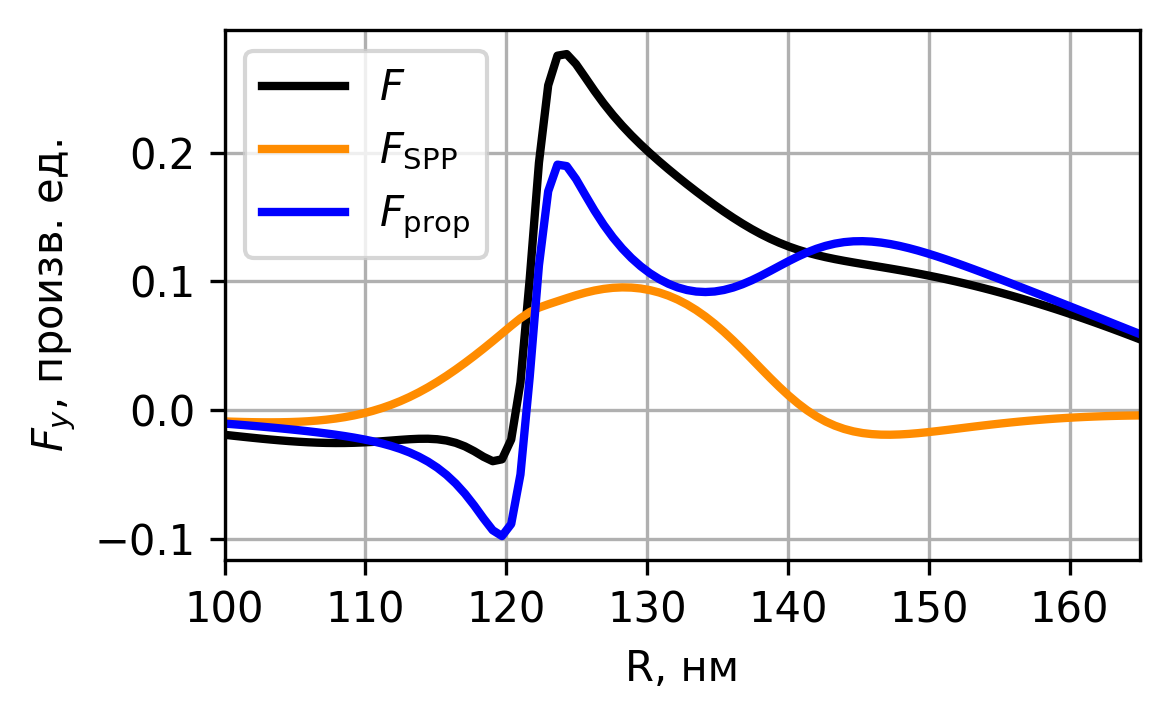

In [58]:
plt.figure(figsize=(4, 2.5), dpi=300)
plt.plot(two_sweep_res.R,  two_sweep_res.Fy/F0, lw=2, c='black', label="$F$")

plt.plot(two_sweep_res.R, two_sweep_res.Fyspp/F0, lw=2, c='darkorange', label="$F_{\\text{SPP}}$")

plt.plot(two_sweep_res.R, (two_sweep_res.Fy - two_sweep_res.Fyspp)/F0, lw=2, c='blue', label="$F_{\\text{prop}}$")

plt.xlabel('R, нм')
plt.ylabel('$F_y$, произв. ед.')
# plt.yticks([-pi, -pi/2, 0, pi/2, pi], ['$-\\pi$', '$-\\pi/2$', '$0$', '$\\pi/2$', '$\\pi$'])
# plt.title('Two-beam incidence')
plt.xlim(two_sweep_res.R.magnitude.min(), two_sweep_res.R.magnitude.max())
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig('proceeding/Fy_components_two_beam.png', dpi=300)
plt.show()

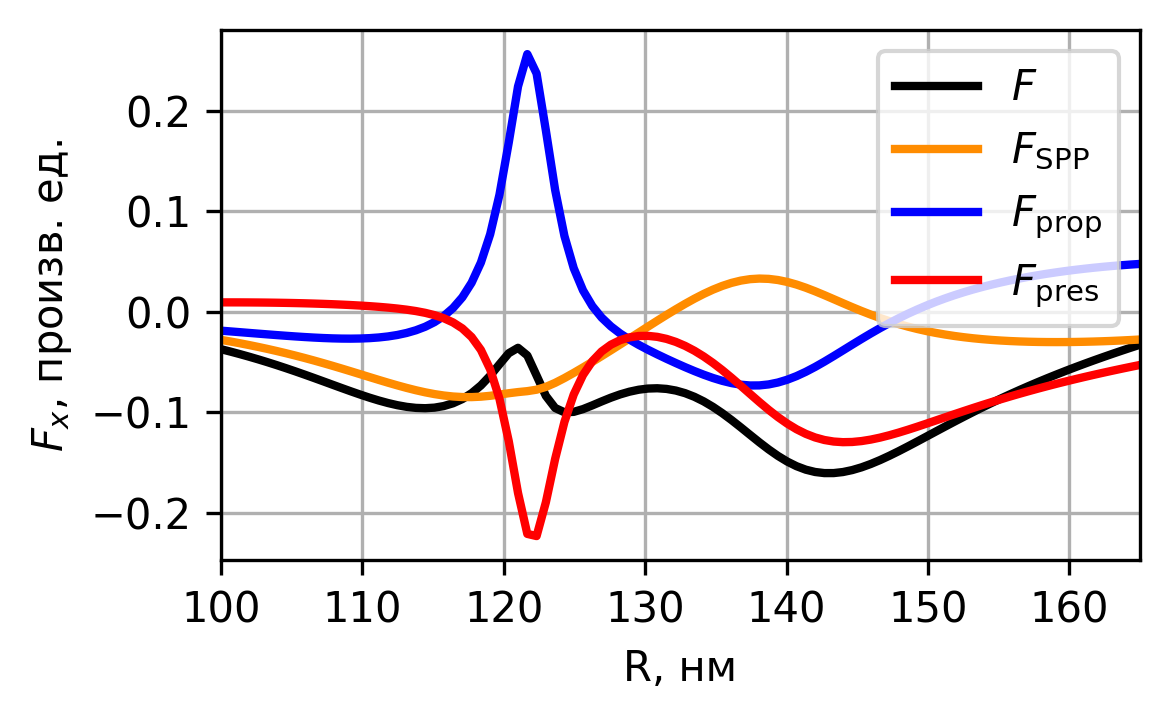

In [59]:
Fx_no_sc = two_sweep_res.Fx - two_sweep_res.Fxe0 - two_sweep_res.Fxm0


plt.figure(figsize=(4, 2.5), dpi=300)
plt.plot(two_sweep_res.R,  two_sweep_res.Fx/F0, lw=2, c='black', label="$F$")

plt.plot(two_sweep_res.R, two_sweep_res.Fxspp/F0, lw=2, c='darkorange', label="$F_{\\text{SPP}}$")

plt.plot(two_sweep_res.R, (Fx_no_sc - two_sweep_res.Fxspp)/F0, lw=2, c='blue', label="$F_{\\text{prop}}$")

# plt.plot(two_sweep_res.R, Fx_no_sc/F0, lw=2, c='blue', label="$F_{\\text{ППП}}+F_{\\text{воздух}}$")
plt.plot(two_sweep_res.R, two_sweep_res.Fx/F0 - Fx_no_sc/F0, lw=2, c='red', label="$F_{\\text{pres}}$")

plt.xlabel('R, нм')
plt.ylabel('$F_x$, произв. ед.')
# plt.yticks([-pi, -pi/2, 0, pi/2, pi], ['$-\\pi$', '$-\\pi/2$', '$0$', '$\\pi/2$', '$\\pi$'])
plt.xlim(two_sweep_res.R.magnitude.min(), two_sweep_res.R.magnitude.max())
plt.grid()
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('proceeding/Fx_components_two_beam.png', dpi=300)
plt.show()

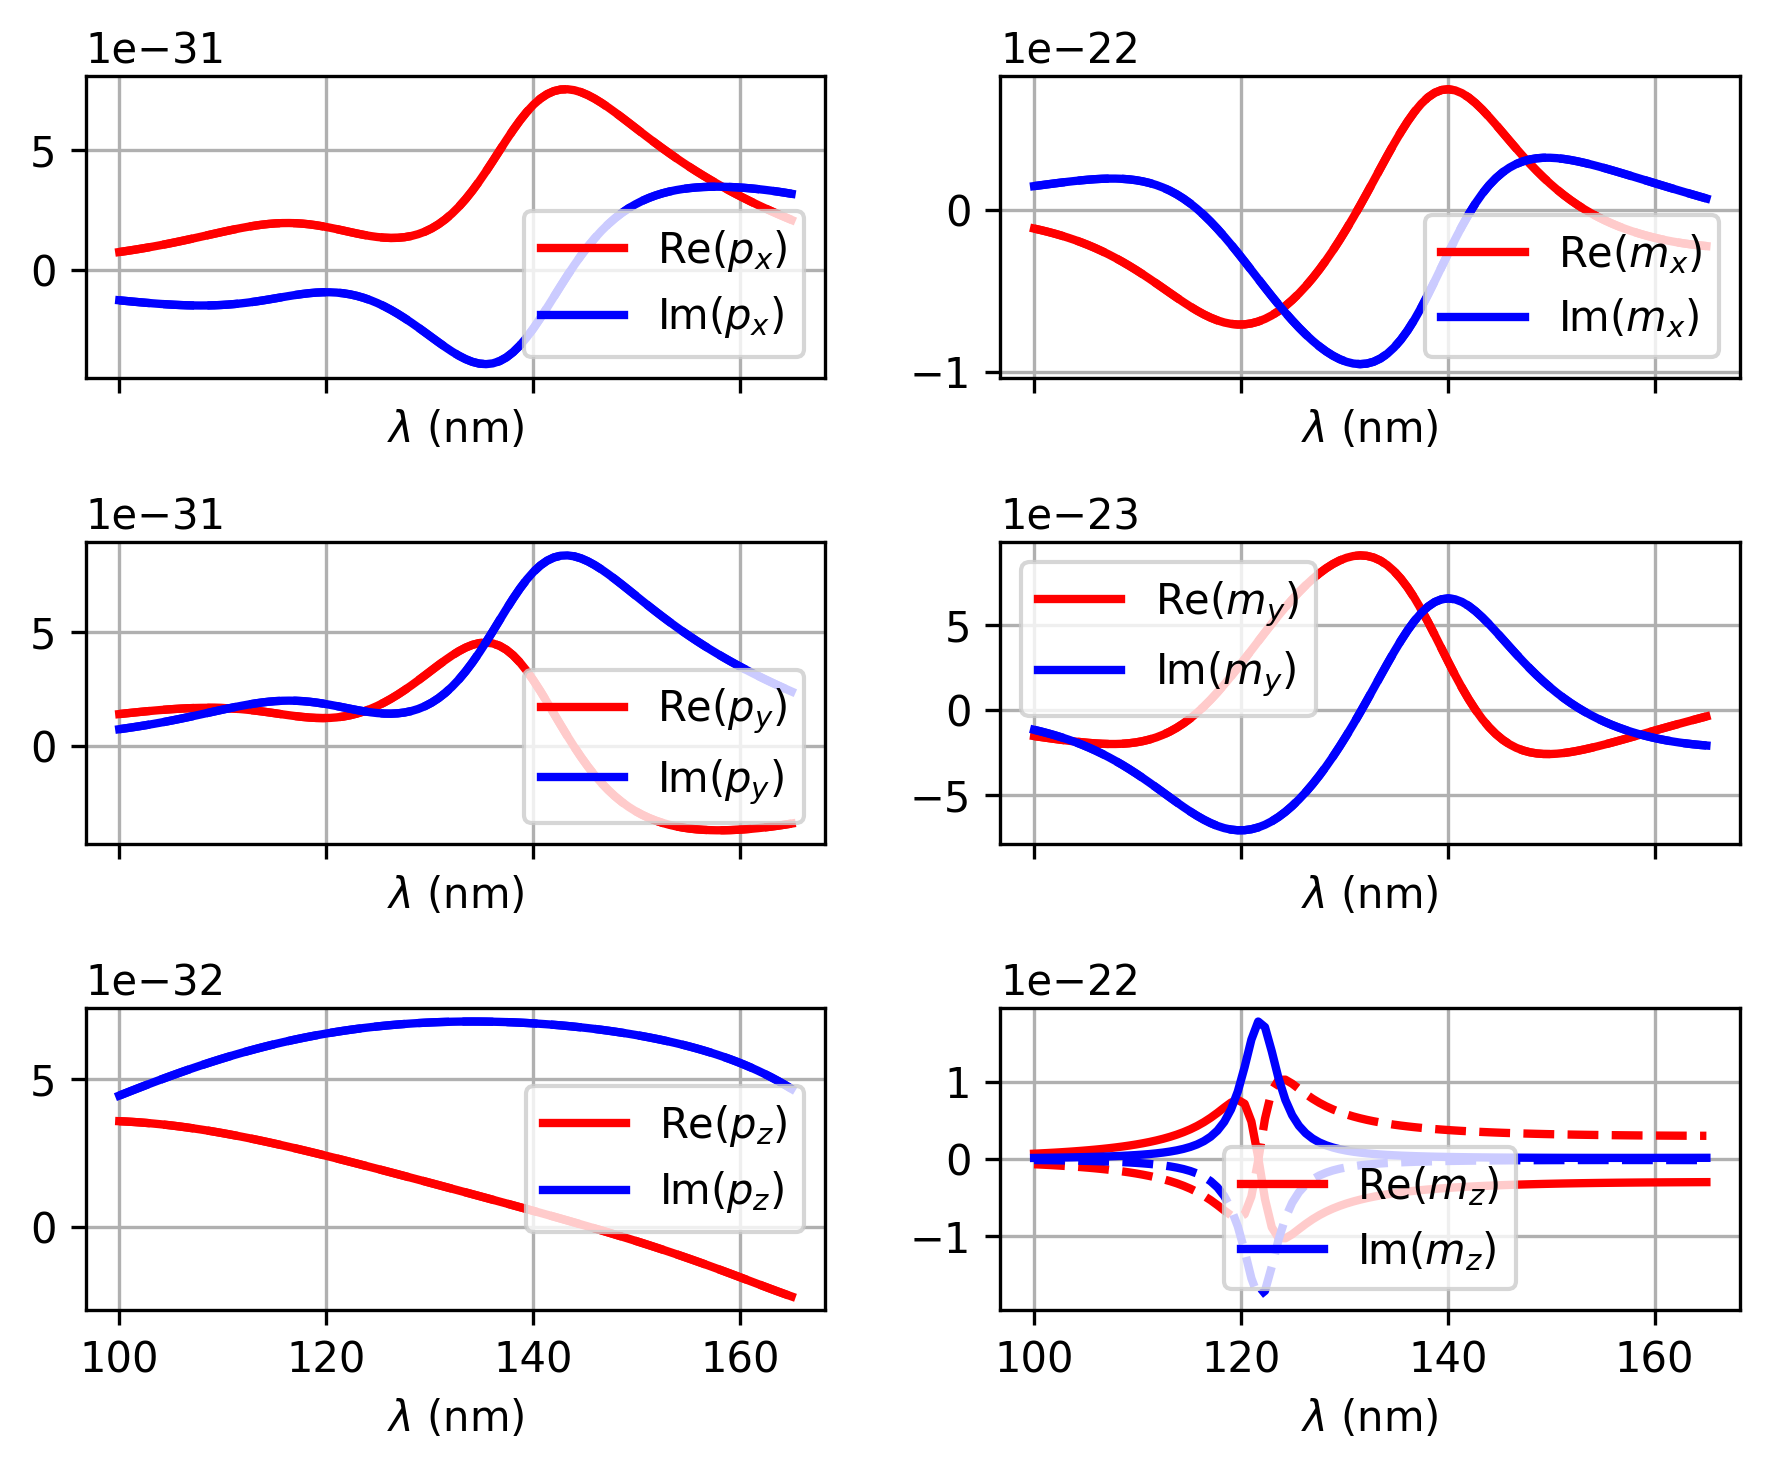

In [60]:
import numpy as np
import matplotlib.pyplot as plt


# --- 2. Угол силы ---
px_one = one_sweep_res.px.magnitude
py_one = one_sweep_res.py.magnitude
pz_one = one_sweep_res.pz.magnitude
mx_one = one_sweep_res.mx.magnitude
my_one = one_sweep_res.my.magnitude
mz_one = one_sweep_res.mz.magnitude

# --- 2. Угол силы ---
px_two = two_sweep_res.px.magnitude
py_two = two_sweep_res.py.magnitude
pz_two = two_sweep_res.pz.magnitude
mx_two = two_sweep_res.mx.magnitude
my_two = two_sweep_res.my.magnitude
mz_two = two_sweep_res.mz.magnitude

dips_one=[[px_one,py_one,pz_one],[mx_one,my_one,mz_one]]

dips_two = [[px_two,py_two,pz_two],[mx_two,my_two,mz_two]]

labels=[['$p_x$','$p_y$','$p_z$'],['$m_x$','$m_y$','$m_z$']]

R = one_sweep_res.R

# --- графики ---
fig, axs = plt.subplots(3, 2, figsize=(6, 5),dpi=300, sharex=True)

for i in range(2):
    for j in range(3):
        axs[j,i].plot(R, dips_one[i][j].real, label='Re('+labels[i][j]+')', lw=2, c='r')
        axs[j,i].plot(R, dips_two[i][j].real, lw=2, c='r', ls='--')
        axs[j,i].plot(R, dips_one[i][j].imag, label='Im('+labels[i][j]+')', lw=2, c='b')
        axs[j,i].plot(R, dips_two[i][j].imag, lw=2, c='b', ls='--')
        axs[j,i].legend()
        axs[j,i].grid()
        axs[j,i].set_xlabel('$\\lambda$ (nm)')

# axs[0].legend()
# axs[0].grid(True)

# # Y-компонента
# #axs[1].plot(wl, Fy_norm, label="$F_y / F_0^{max}$", lw=3)
# axs[1].plot(wl, Fy01, label="$F_{y,\\;sc}/ F_0^{max}$", lw=3)

# # axs[1].set_ylabel("$F_y^{spp}$ / $F_0^{max}$")
# axs[1].set_xlabel("$R$ (nm)")
# axs[1].legend()
# axs[1].grid(True)

# plt.suptitle("Force Components")
plt.tight_layout()
#plt.savefig('plots/Force_01_and_Cross.png', dpi=300)
plt.show()

In [61]:
import numpy as np
import matplotlib.pyplot as plt

res1 = one_sweep_res
res2 = two_sweep_res

Fx_nosc_one = res1.Fx - res1.Fxe0 - res1.Fxm0
Fx_nosc_noncross_one = Fx_nosc_one - res1.Fxcross
Fy_nosc_noncross_one = res1.Fy - res1.Fycross

Fy01_one = res1.Fy - res1.Fycross - res1.Fyspp 
Fx01_one = res1.Fx - res1.Fxcross - res1.Fxspp - res1.Fxe0 - res1.Fxm0


In [62]:
Fx_nosc_two = res2.Fx - res2.Fxe0 - res2.Fxm0

Fx_nosc_noncross_two = Fx_nosc_two - res2.Fxcross
Fy_nosc_noncross_two = res2.Fy - res2.Fycross

Fy01_two = res2.Fy - res2.Fycross - res2.Fyspp 
Fx01_two = res2.Fx - res2.Fxcross - res2.Fxspp - res2.Fxe0 - res2.Fxm0


In [63]:
def make_plot(loc='best'):
    plt.grid()
    plt.xlabel('R (нм)')
    plt.legend(loc=loc)
    plt.show()

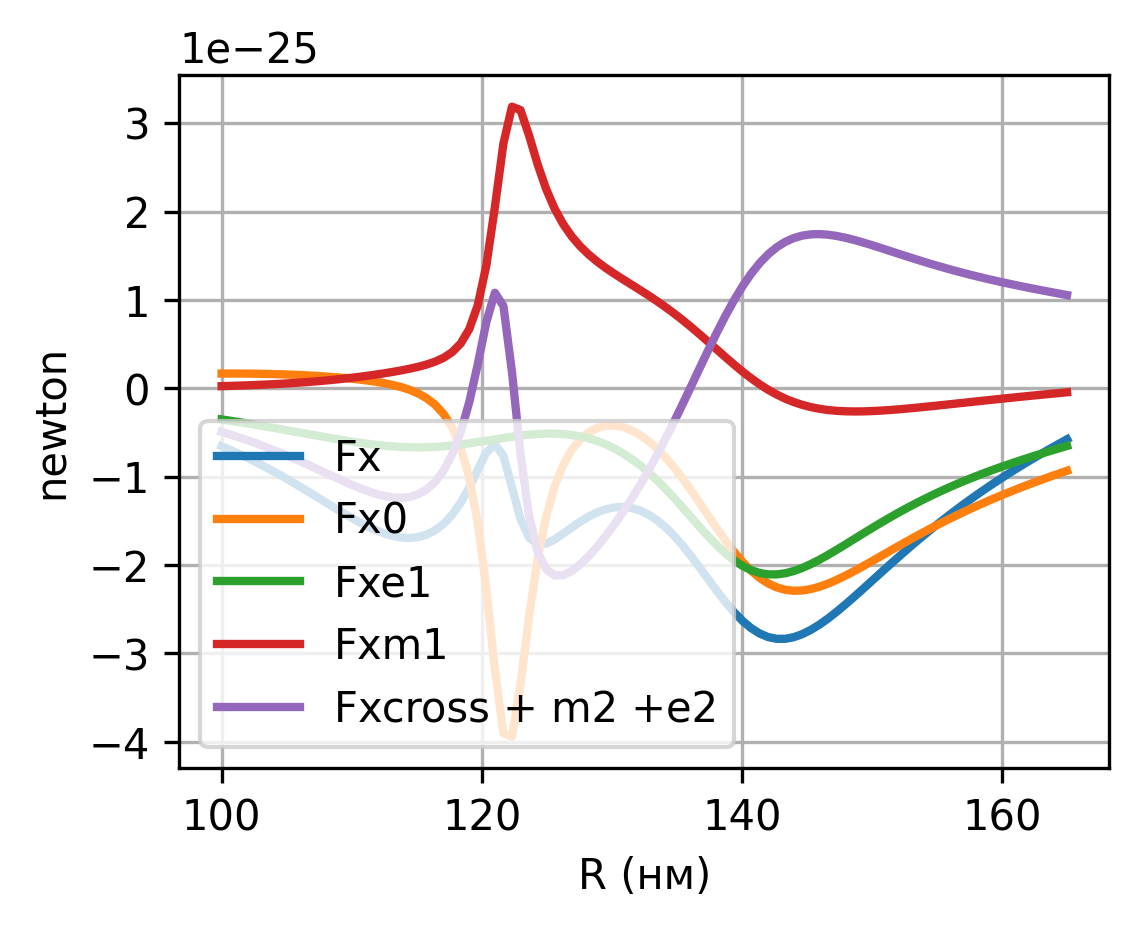

In [64]:
plt.figure(figsize=(4,3), dpi=300)

plt.plot(R, res2.Fx, label='Fx', lw=2)
# plt.plot(R, res2.Fxe0, label='Fxe0', lw=2)
plt.plot(R, res2.Fxm0+res2.Fxe0, label='Fx0', lw=2)

plt.plot(R, res2.Fxe1, label='Fxe1', lw=2)
plt.plot(R, res2.Fxm1, label='Fxm1', lw=2)

# plt.plot(R, Fxe2_two, label='Fxe2', lw=2)
# plt.plot(R, res2.Fxm2, label='Fxm2', lw=2)

plt.plot(R, res2.Fxcross + res2.Fxe2 + res2.Fxm2, label='Fxcross + m2 +e2', lw=2)

make_plot('lower left')

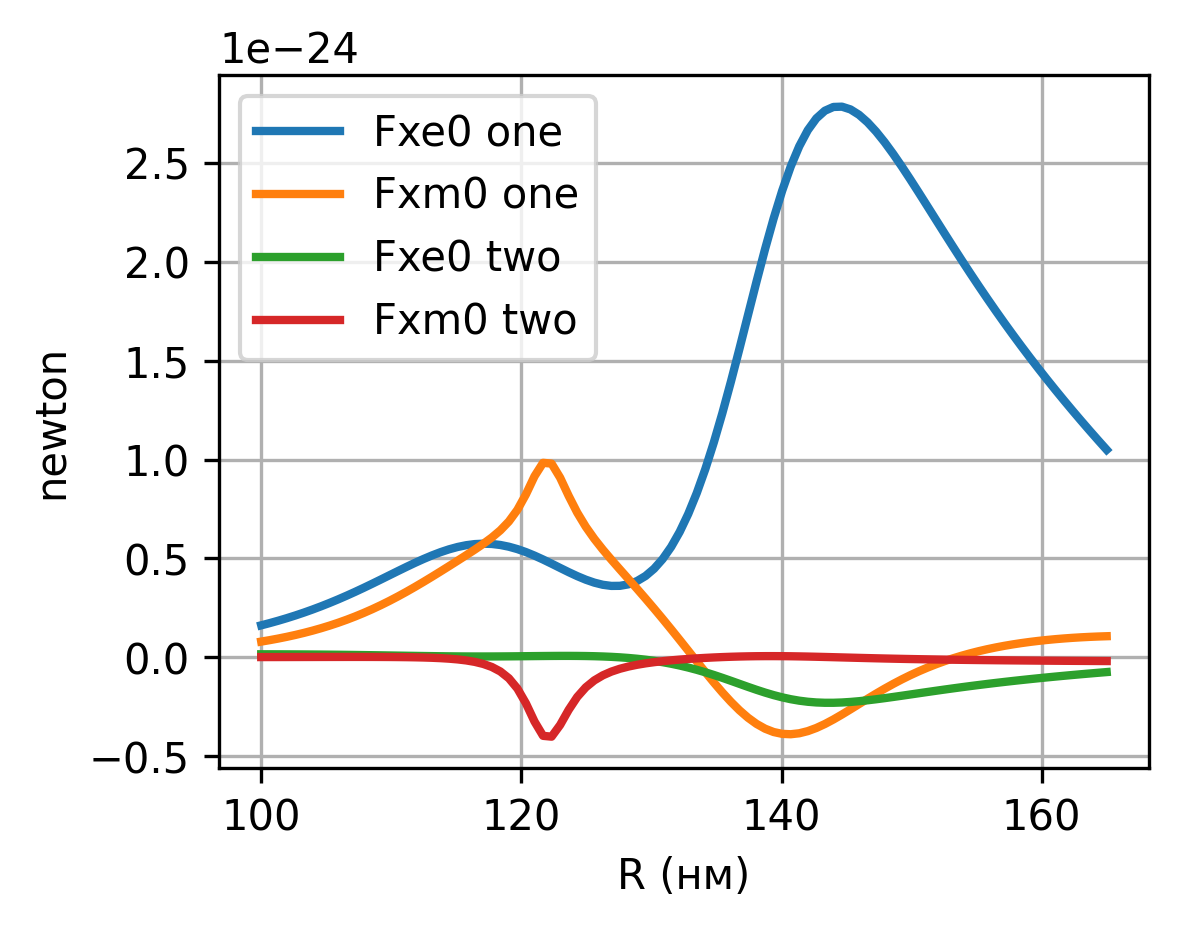

In [65]:
plt.figure(figsize=(4,3), dpi=300)

plt.plot(R, res1.Fxe0, label='Fxe0 one', lw=2)
plt.plot(R, res1.Fxm0, label='Fxm0 one', lw=2)

plt.plot(R, res2.Fxe0, label='Fxe0 two', lw=2)
plt.plot(R, res2.Fxm0, label='Fxm0 two', lw=2)

make_plot()

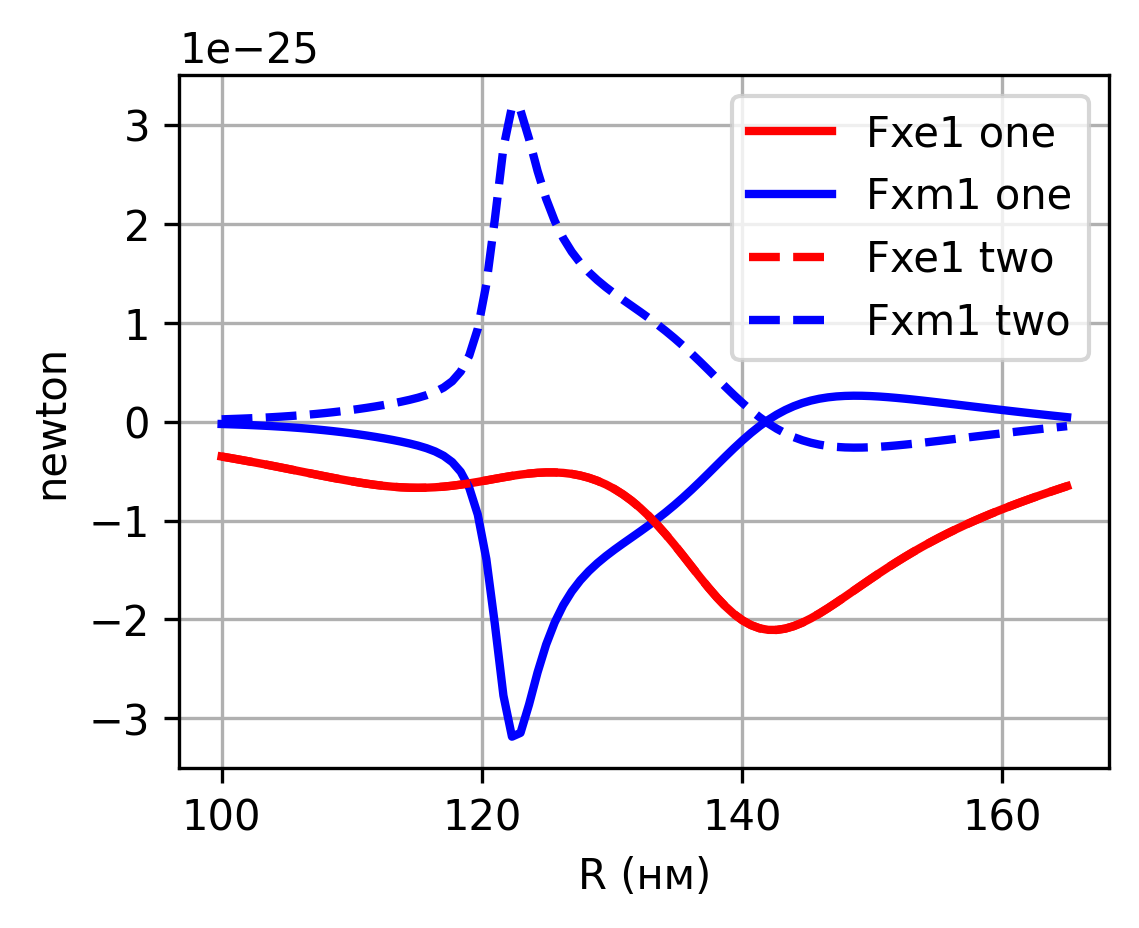

In [66]:
plt.figure(figsize=(4,3), dpi=300)

plt.plot(R, res1.Fxe1, label='Fxe1 one', c='r', lw=2)
plt.plot(R, res1.Fxm1, label='Fxm1 one', c='b',lw=2)

plt.plot(R, res2.Fxe1, label='Fxe1 two', c='r', ls='--', lw=2)
plt.plot(R, res2.Fxm1, label='Fxm1 two', c='b', ls='--', lw=2)


make_plot()

$$

F_x^{p_y^* m_z + \times} =  - \omega \mu_0 \left( Im( \partial_x[\nabla \times \hat{G}^H_{yz} ]) + \frac{k^3}{12 \pi} \right) Re(p_y^* m_z) 

$$



$$
F_x^{p_z^* m_y + \times} = - \omega \mu_0 \left( Im( \partial_x [\nabla \times \hat{G}^H_{zy}]) - \frac{k^3}{12 \pi} \right) Re(p_z^* m_y)
$$

In [67]:
from MieSppForce.green_func import dx_rot_green_E_H

dxrotGH = np.zeros((len(R),3,3), dtype=complex)
for i in range(len(R)):
    dxrotGH[i,:,:] = dx_rot_green_E_H(wl=one_beam_base_config.wl.to(ureg.nanometer).magnitude, 
                                      z0=one_beam_base_config.dist.to(ureg.nanometer).magnitude+
                                        + R[i].to(ureg.nanometer).magnitude, 
                                      eps_interp=one_beam_base_config.eps_substrate,
                                      stop=45)[1]


In [68]:
c_const = 299792458
k = 2 * np.pi / one_beam_base_config.wl.to(ureg.meter).magnitude
omega = c_const * k
mu0 = 4 * np.pi * 1e-7
eps0_const = 1/(4*np.pi*c_const**2)*1e7 

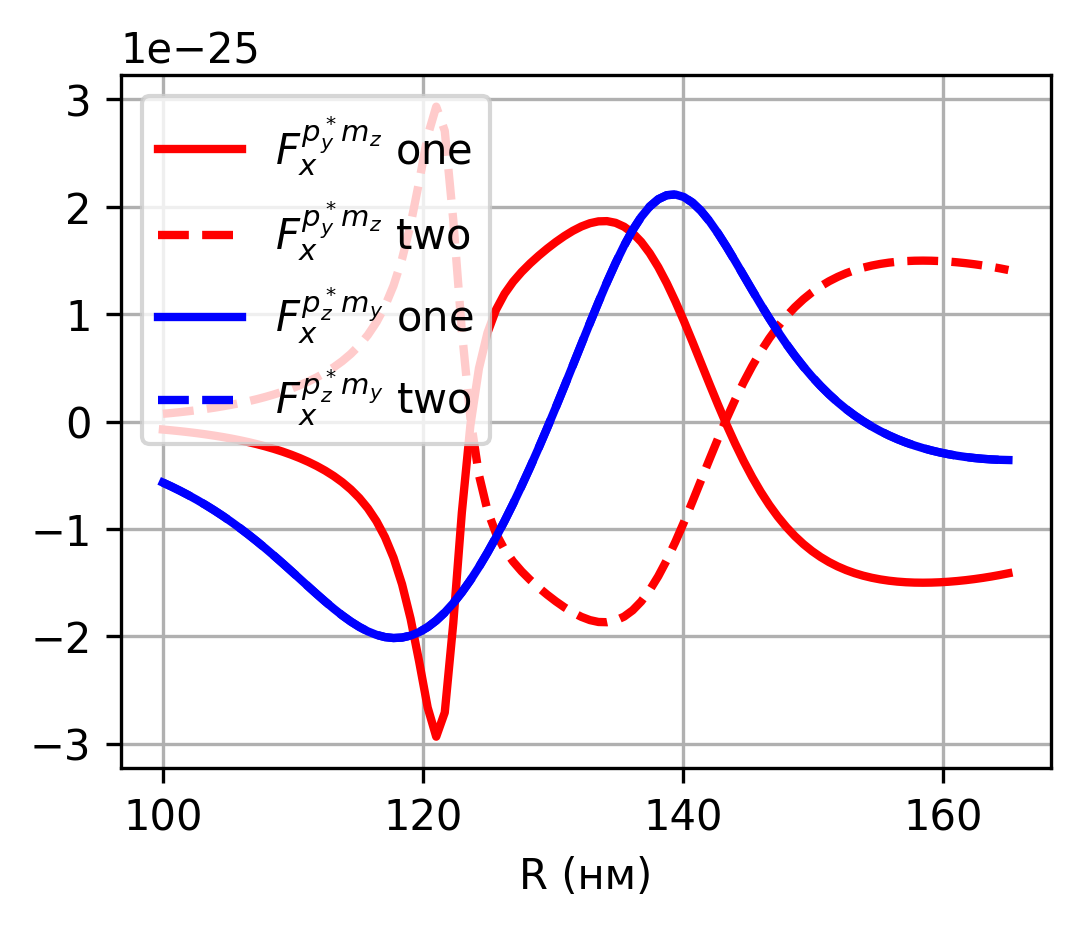

In [69]:
plt.figure(figsize=(4,3), dpi=300)

plt.plot(R, -omega*mu0* (np.imag(dxrotGH[:,1,2])+k**3/(12*np.pi))*np.real(py_one.conj()*mz_one), label='$F_x^{p_y^* m_z}$ one', c='r', lw=2)

plt.plot(R, -omega*mu0* (np.imag(dxrotGH[:,1,2])+ k**3/(12*np.pi))*np.real(py_two.conj()*mz_two), label='$F_x^{p_y^* m_z}$ two', c='r', ls='--', lw=2)

plt.plot(R, -omega*mu0* (np.imag(dxrotGH[:,2,1])- k**3/(12*np.pi))*np.real(pz_one.conj()*my_one), label='$F_x^{p_z^* m_y}$ one', c='b', lw=2)
plt.plot(R, -omega*mu0* (np.imag(dxrotGH[:,2,1])- k**3/(12*np.pi))*np.real(pz_two.conj()*my_two), label='$F_x^{p_z^* m_y}$ two', c='b', ls='--', lw=2)


make_plot(loc='upper left')


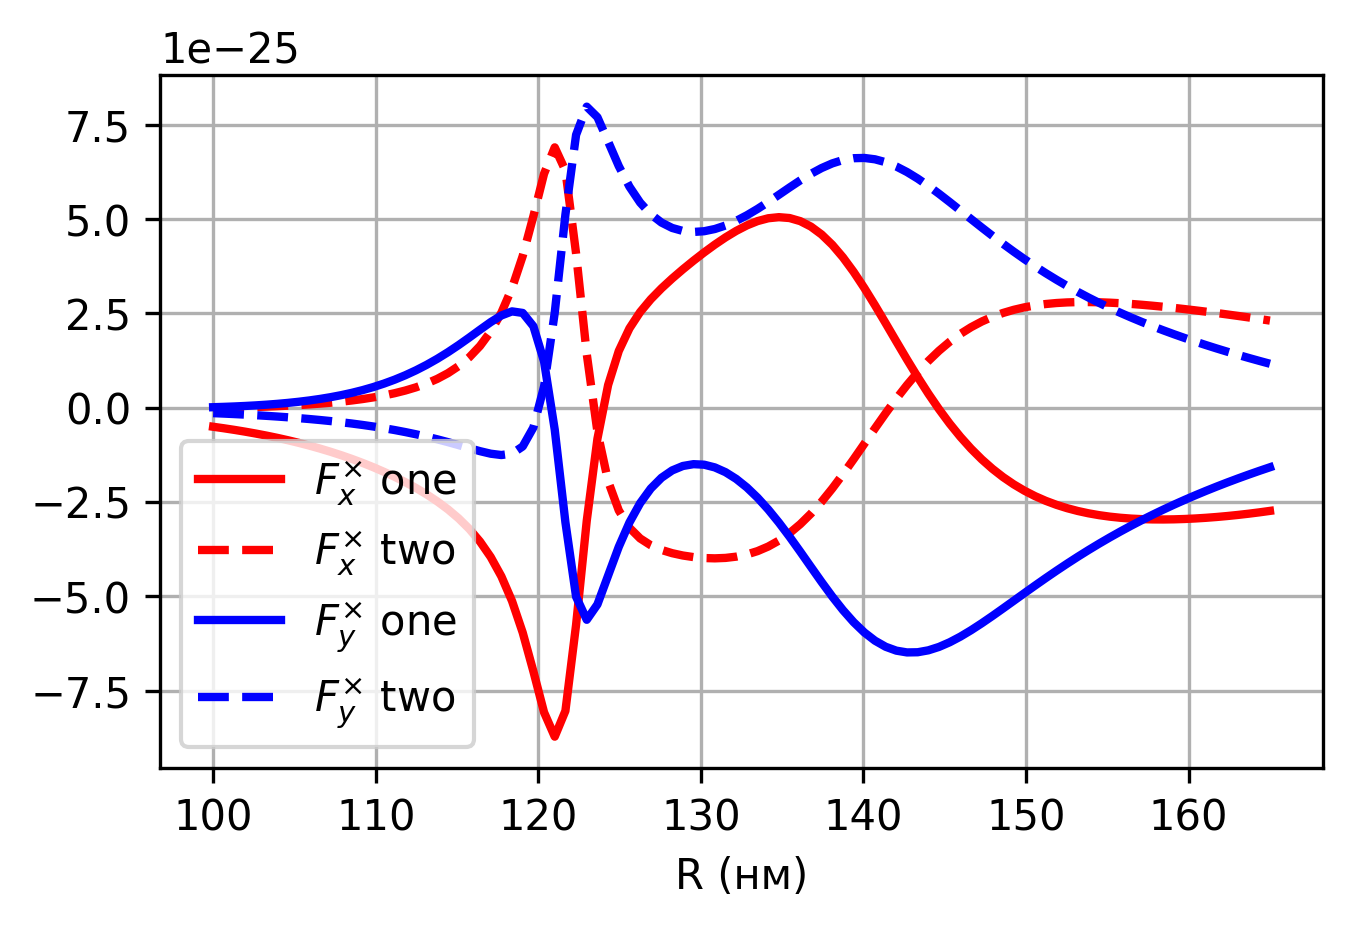

In [70]:
plt.figure(figsize=(5,3), dpi=300)
plt.plot(R, -k**4/(12*np.pi*c_const*eps0_const) * np.real( py_one*mz_one.conj() - pz_one*my_one.conj()), label='$F_x^{\\times}$ one', c='r', lw=2)
plt.plot(R, -k**4/(12*np.pi*c_const*eps0_const) * np.real( py_two*mz_two.conj() - pz_two*my_two.conj()), label='$F_x^{\\times}$ two', c='r',ls='--', lw=2)


plt.plot(R, -k**4/(12*np.pi*c_const*eps0_const) * np.real( pz_one*mx_one.conj() - px_one*mz_one.conj()), label='$F_y^{\\times}$ one', c='b', lw=2)
plt.plot(R, -k**4/(12*np.pi*c_const*eps0_const) * np.real( pz_two*mx_two.conj() - px_two*mz_two.conj()), label='$F_y^{\\times}$ two', c='b',ls='--', lw=2)


make_plot('best')

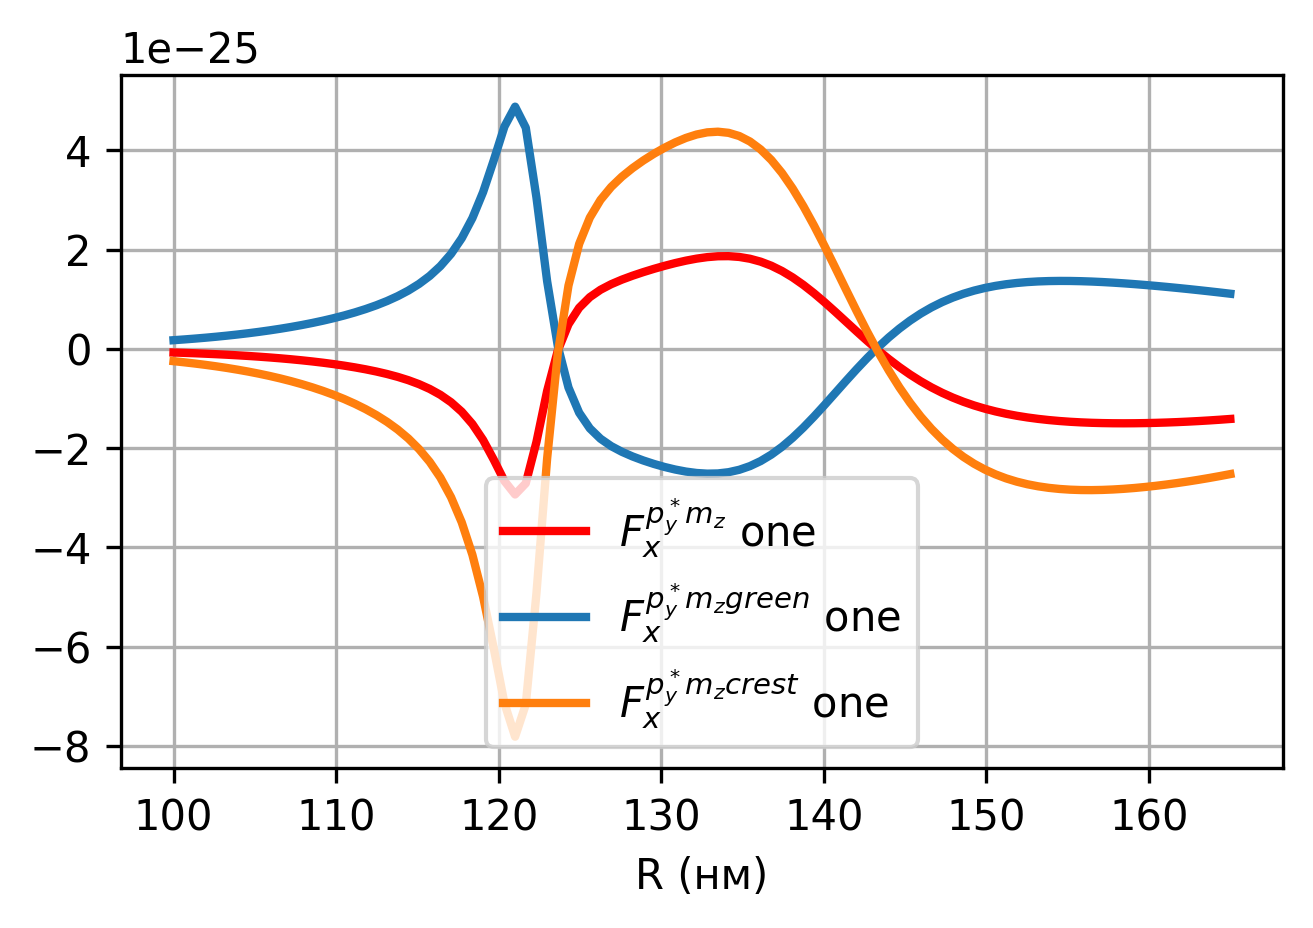

In [71]:
plt.figure(figsize=(5,3), dpi=300)
plt.plot(R, -omega*mu0* (np.imag(dxrotGH[:,1,2,])+k**3/(12*np.pi))*np.real(py_one.conj()*mz_one), label='$F_x^{p_y^* m_z}$ one', c='r', lw=2)
plt.plot(R, -omega*mu0* (np.imag(dxrotGH[:,1,2,]))*np.real(py_one.conj()*mz_one), label='$F_x^{p_y^* m_z green}$ one', lw=2 )
plt.plot(R, -omega*mu0* (k**3/(12*np.pi))*np.real(py_one.conj()*mz_one), label='$F_x^{p_y^* m_z crest}$ one', lw=2)


# plt.plot(R, -omega*mu0* (np.imag(dxrotGH[:,1,2,])+ k**3/(12*np.pi))*np.real(py_two.conj()*mz_two), label='$F_x^{p_y^* m_z}$ two', c='r', ls='--', lw=2)
make_plot(loc='best')

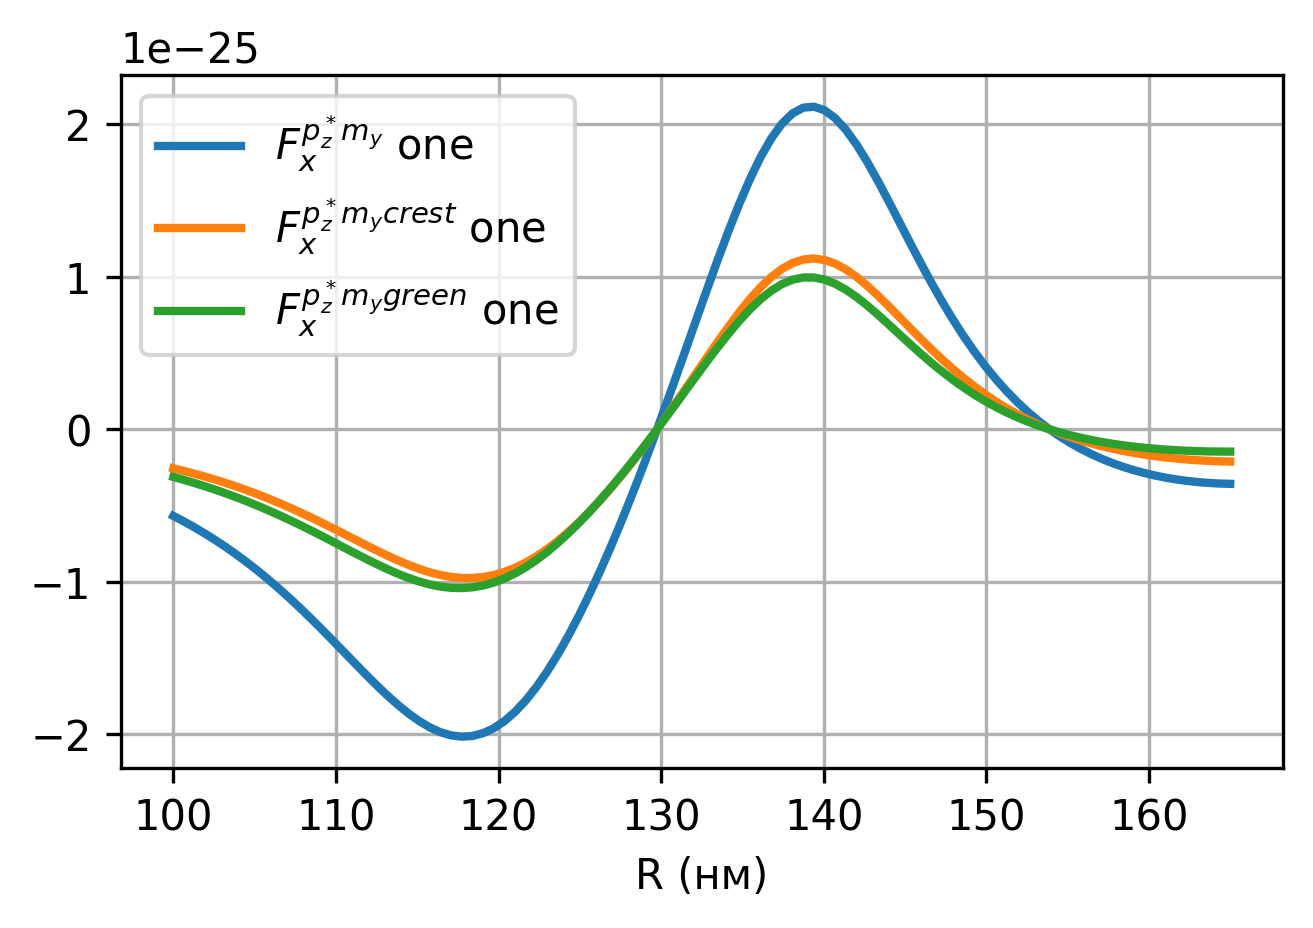

In [72]:
plt.figure(figsize=(5,3), dpi=300)
plt.plot(R, -omega*mu0* (np.imag(dxrotGH[:,2,1])- k**3/(12*np.pi))*np.real(pz_one.conj()*my_one), label='$F_x^{p_z^* m_y}$ one',  lw=2)
plt.plot(R, omega*mu0*  k**3/(12*np.pi)*np.real(pz_one.conj()*my_one), label='$F_x^{p_z^* m_y crest}$ one', lw=2)

plt.plot(R, -omega*mu0* np.imag(dxrotGH[:,2,1])*np.real(pz_one.conj()*my_one), label='$F_x^{p_z^* m_y green}$ one', lw=2)

make_plot(loc='best')

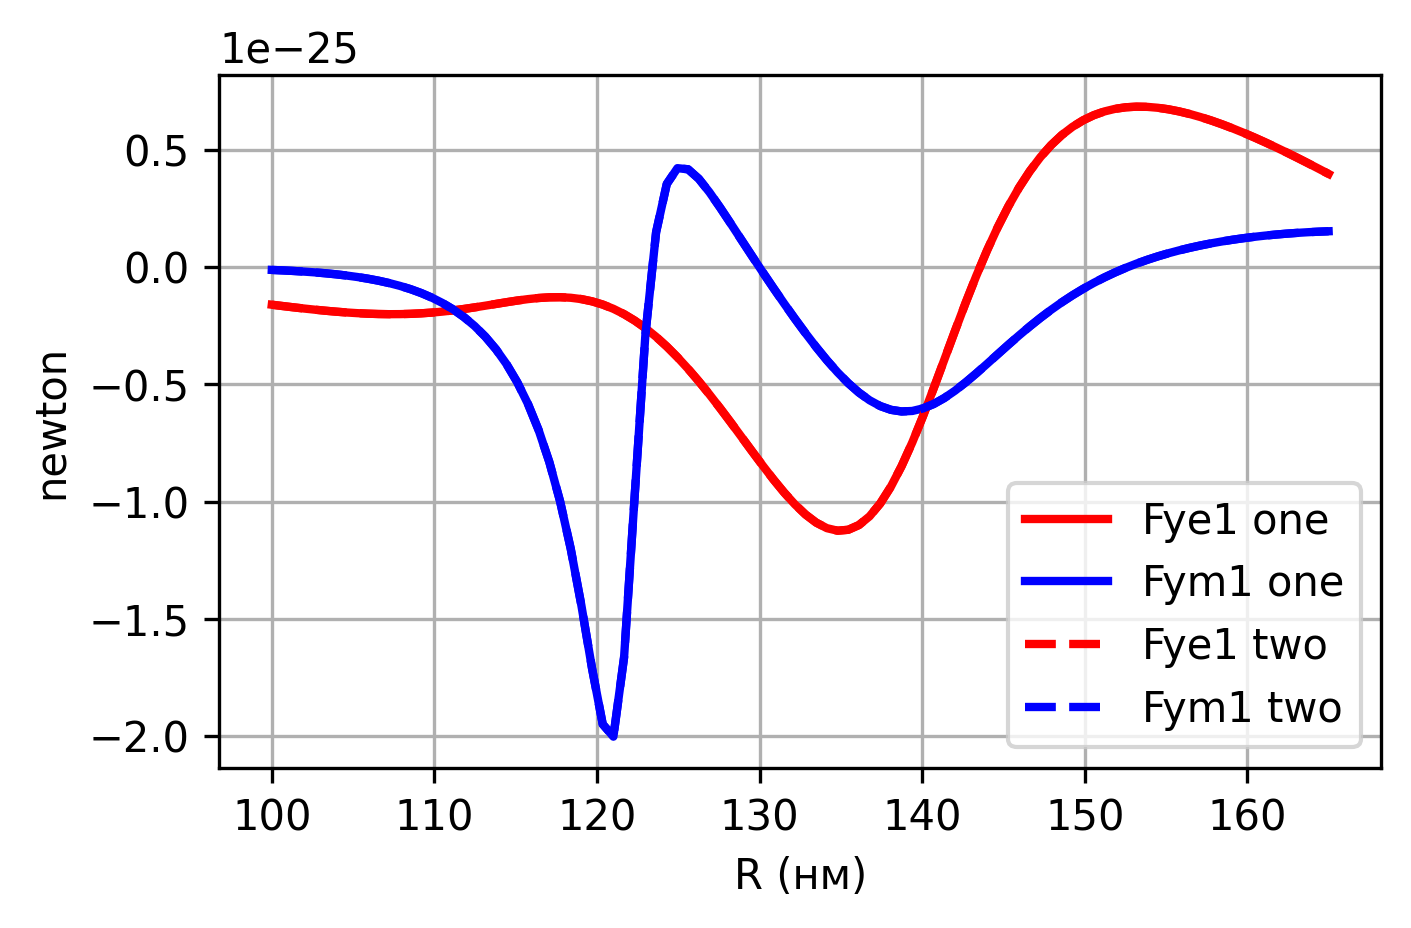

In [73]:
plt.figure(figsize=(5,3), dpi=300)
plt.plot(R, res1.Fye1, label='Fye1 one', c='r', lw=2)
plt.plot(R, res2.Fym1, label='Fym1 one', c='b',lw=2)

plt.plot(R, res1.Fye1, label='Fye1 two', c='r', ls='--', lw=2)
plt.plot(R, res2.Fym1, label='Fym1 two', c='b', ls='--', lw=2)


make_plot('best')

$$
F_y^{p_x^* m_z + \times} = -\omega \mu_0 \left( Im(\partial_y [\nabla \times \hat{G}^H_{xz} ]) - \frac{k^3}{12 \pi} \right) Re(p_x^* m_z) 

$$

$$
F_y^{p_z^* m_x + \times} = -\omega \mu_0 \left( Im( \partial_y  [\nabla \times \hat{G}^H_{zx}] )+ \frac{k^3}{12 \pi} \right) Re(p_z^* m_x)

$$

In [74]:
from MieSppForce.green_func import dy_rot_green_E_H

dyrotGH = np.zeros((len(R),3,3), dtype=complex)
for i in range(len(R)):
    dyrotGH[i,:,:] = dy_rot_green_E_H(wl=one_beam_base_config.wl.to(ureg.nanometer).magnitude, 
                                      z0=one_beam_base_config.dist.to(ureg.nanometer).magnitude+
                                        + R[i].to(ureg.nanometer).magnitude, 
                                      eps_interp=one_beam_base_config.eps_substrate,
                                      stop=45)[1]


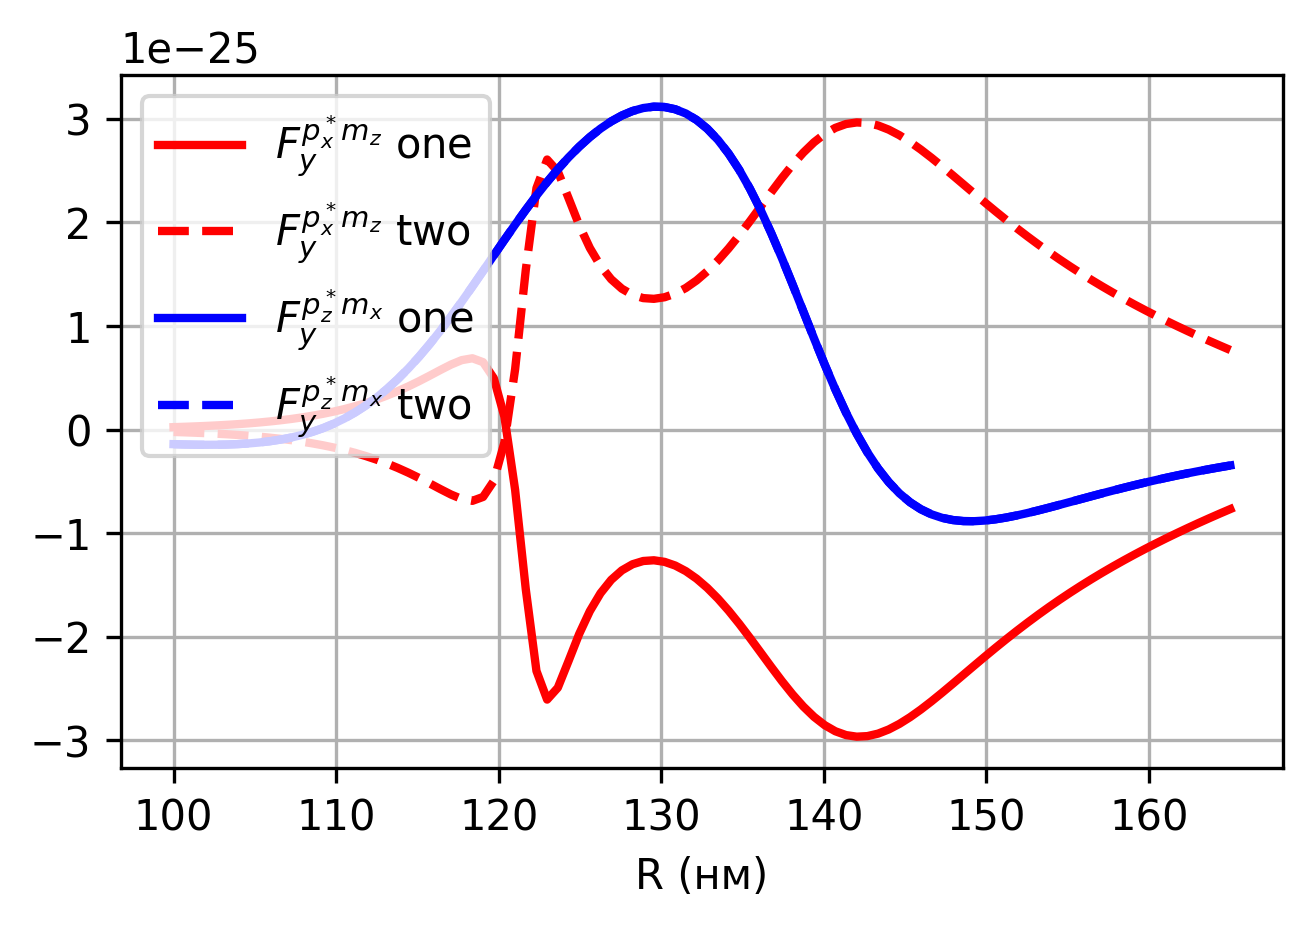

In [75]:
plt.figure(figsize=(5,3), dpi=300)

plt.plot(R, -omega*mu0* (np.imag(dyrotGH[:,0,2])-k**3/(12*np.pi))*np.real(px_one.conj()*mz_one), label='$F_y^{p_x^* m_z}$ one', c='r', lw=2)

plt.plot(R, -omega*mu0* (np.imag(dyrotGH[:,0,2])- k**3/(12*np.pi))*np.real(px_two.conj()*mz_two), label='$F_y^{p_x^* m_z}$ two', c='r', ls='--', lw=2)

plt.plot(R, -omega*mu0* (np.imag(dyrotGH[:,2,0])+ k**3/(12*np.pi))*np.real(pz_one.conj()*mx_one), label='$F_y^{p_z^* m_x}$ one', c='b', lw=2)
plt.plot(R, -omega*mu0* (np.imag(dyrotGH[:,2,0])+ k**3/(12*np.pi))*np.real(pz_two.conj()*mx_two), label='$F_y^{p_z^* m_x}$ two', c='b', ls='--', lw=2)


make_plot('upper left')

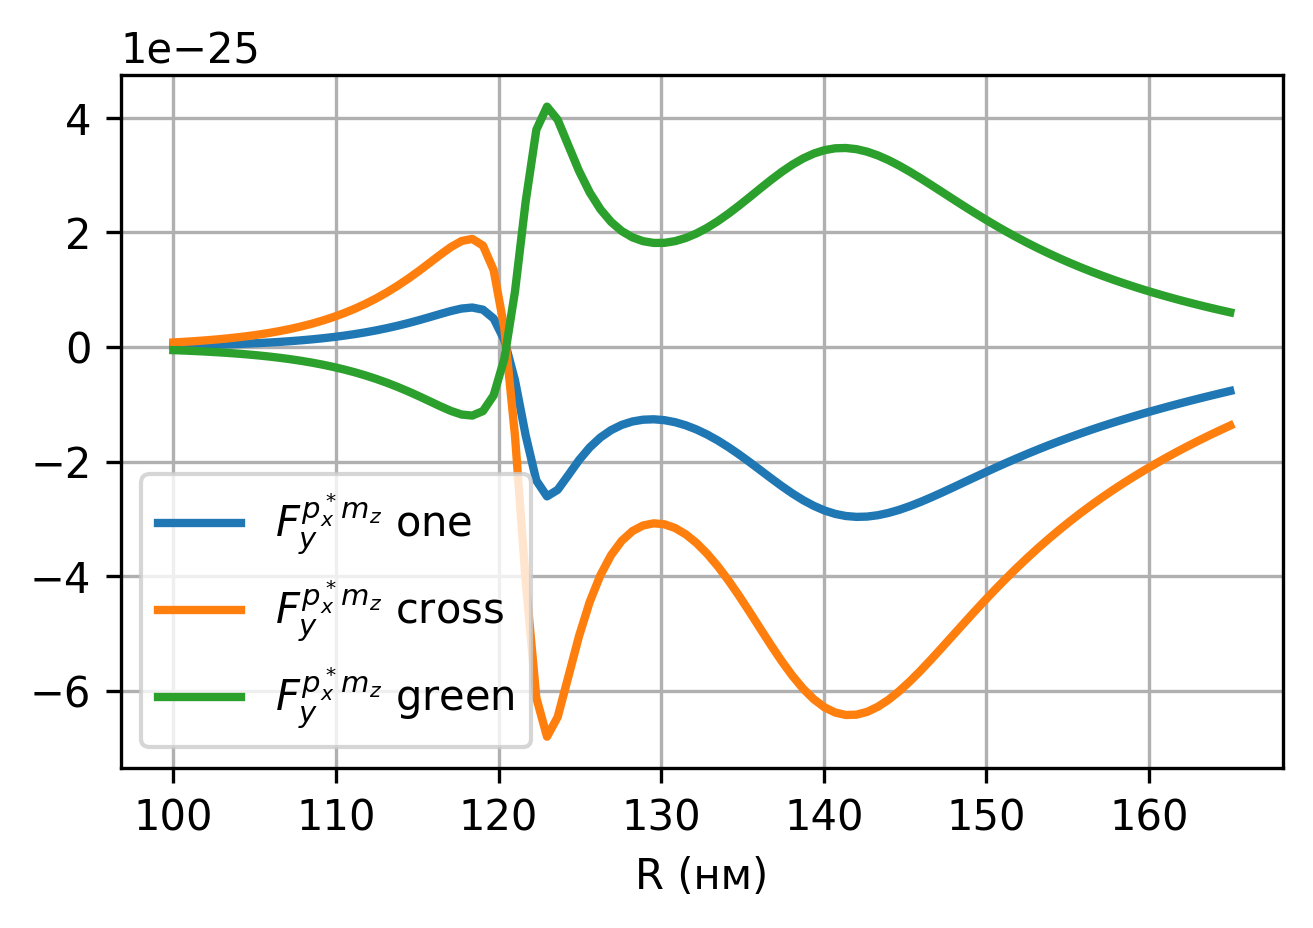

In [76]:
plt.figure(figsize=(5,3), dpi=300)

plt.plot(R, -omega*mu0* (np.imag(dyrotGH[:,0,2])-k**3/(12*np.pi))*np.real(px_one.conj()*mz_one), label='$F_y^{p_x^* m_z}$ one', lw=2)

plt.plot(R, -omega*mu0* (-k**3/(12*np.pi))*np.real(px_one.conj()*mz_one), label='$F_y^{p_x^* m_z}$ cross', lw=2)

plt.plot(R, -omega*mu0* (np.imag(dyrotGH[:,0,2]))*np.real(px_one.conj()*mz_one), label='$F_y^{p_x^* m_z}$ green', lw=2)

make_plot('best')

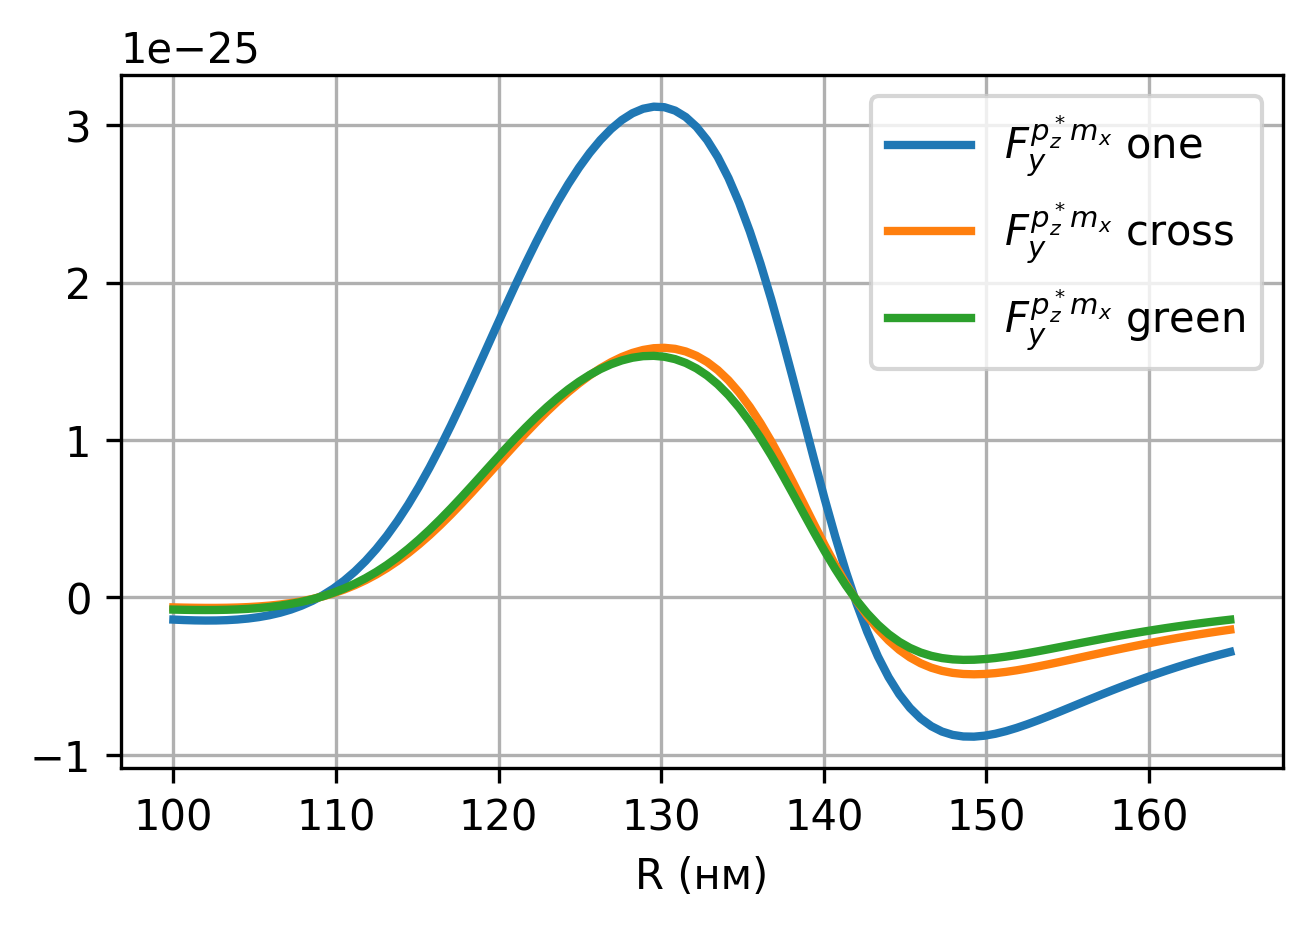

In [77]:
plt.figure(figsize=(5,3), dpi=300)

plt.plot(R, -omega*mu0* (np.imag(dyrotGH[:,2,0])+ k**3/(12*np.pi))*np.real(pz_one.conj()*mx_one), label='$F_y^{p_z^* m_x}$ one', lw=2)

plt.plot(R, -omega*mu0* ( k**3/(12*np.pi))*np.real(pz_one.conj()*mx_one), label='$F_y^{p_z^* m_x}$ cross', lw=2)

plt.plot(R, -omega*mu0* (np.imag(dyrotGH[:,2,0]))*np.real(pz_one.conj()*mx_one), label='$F_y^{p_z^* m_x}$ green', lw=2)

make_plot('best')

In [78]:
from MieSppForce.green_func import dx_rot_green_E_H
from MieSppForce.green_func import dy_rot_green_E_H

dxrotGH01 = np.zeros((len(R),3,3), dtype=complex)
for i in range(len(R)):
    dxrotGH01[i,:,:] = dx_rot_green_E_H(wl=one_beam_base_config.wl.to(ureg.nanometer).magnitude, 
                                      z0=one_beam_base_config.dist.to(ureg.nanometer).magnitude+
                                        + R[i].to(ureg.nanometer).magnitude, 
                                      eps_interp=one_beam_base_config.eps_substrate,
                                      stop=1)[1]
    
dyrotGH01 = np.zeros((len(R),3,3), dtype=complex)
for i in range(len(R)):
    dyrotGH01[i,:,:] = dy_rot_green_E_H(wl=one_beam_base_config.wl.to(ureg.nanometer).magnitude, 
                                      z0=one_beam_base_config.dist.to(ureg.nanometer).magnitude+
                                        + R[i].to(ureg.nanometer).magnitude, 
                                      eps_interp=one_beam_base_config.eps_substrate,
                                      stop=1)[1]
    

dxrotGHspp = dxrotGH - dxrotGH01
dyrotGHspp = dyrotGH - dyrotGH01

In [79]:
Fxe1_one = one_sweep_res.Fxe1
Fye1_one = one_sweep_res.Fye1
Fxm1_one = one_sweep_res.Fxm1
Fym1_one = one_sweep_res.Fym1

Fxe1_spp_one = one_sweep_res.Fxsppe1
Fye1_spp_one = one_sweep_res.Fysppe1

Fxe1_01_one = Fxe1_one - Fxe1_spp_one
Fye1_01_one = Fye1_one - Fye1_spp_one

Fxm1_spp_one = one_sweep_res.Fxsppm1
Fym1_spp_one = one_sweep_res.Fysppm1

Fxm1_01_one = Fxm1_one - Fxm1_spp_one
Fym1_01_one = Fym1_one - Fym1_spp_one

Fxpymz_one = -omega*mu0* (np.imag(dxrotGH[:,1,2])+k**3/(12*np.pi))*np.real(py_one.conj()*mz_one)
Fxpzmy_one = -omega*mu0* (np.imag(dxrotGH[:,2,1])- k**3/(12*np.pi))*np.real(pz_one.conj()*my_one)


Fxpymz_spp_one =  -omega*mu0* (np.imag(dxrotGHspp[:,1,2]))*np.real(py_one.conj()*mz_one)
Fxpzmy_spp_one = -omega*mu0* (np.imag(dxrotGHspp[:,2,1]))*np.real(pz_one.conj()*my_one)

Fxpymz_01_one = Fxpymz_one - Fxpymz_spp_one
Fxpzmy_01_one = Fxpzmy_one - Fxpzmy_spp_one

Fypxmz_one = -omega*mu0* (np.imag(dyrotGH[:,0,2])-k**3/(12*np.pi))*np.real(px_one.conj()*mz_one)
Fypzmx_one = -omega*mu0* (np.imag(dyrotGH[:,2,0])+ k**3/(12*np.pi))*np.real(pz_one.conj()*mx_one)

Fypxmz_spp_one =  -omega*mu0* (np.imag(dyrotGHspp[:,0,2]))*np.real(px_one.conj()*mz_one)
Fypzmx_spp_one = -omega*mu0* (np.imag(dyrotGHspp[:,2,0]))*np.real(pz_one.conj()*mx_one)

Fypxmz_01_one = Fypxmz_one - Fypxmz_spp_one
Fypzmx_01_one = Fypzmx_one - Fypzmx_spp_one

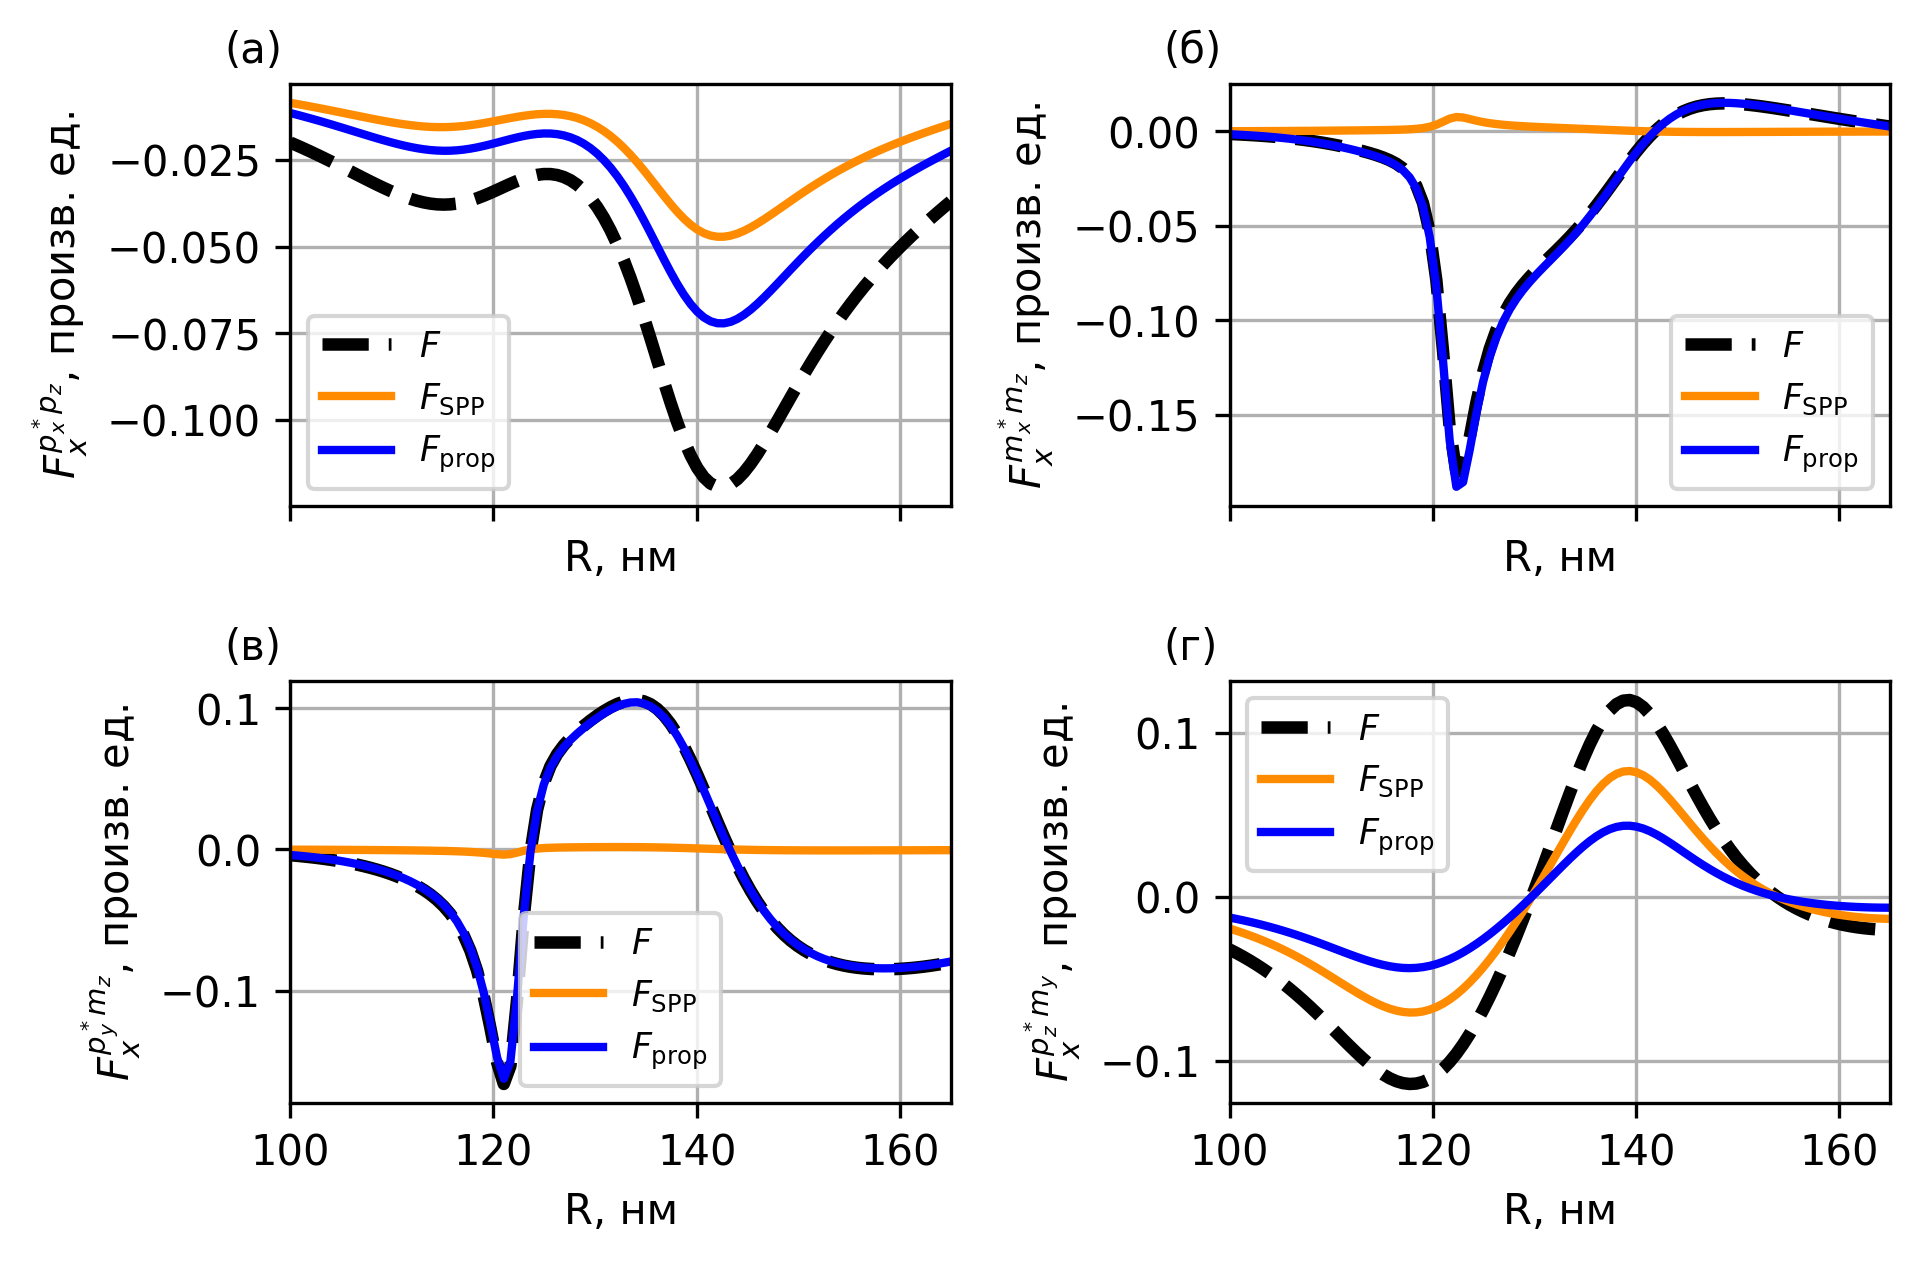

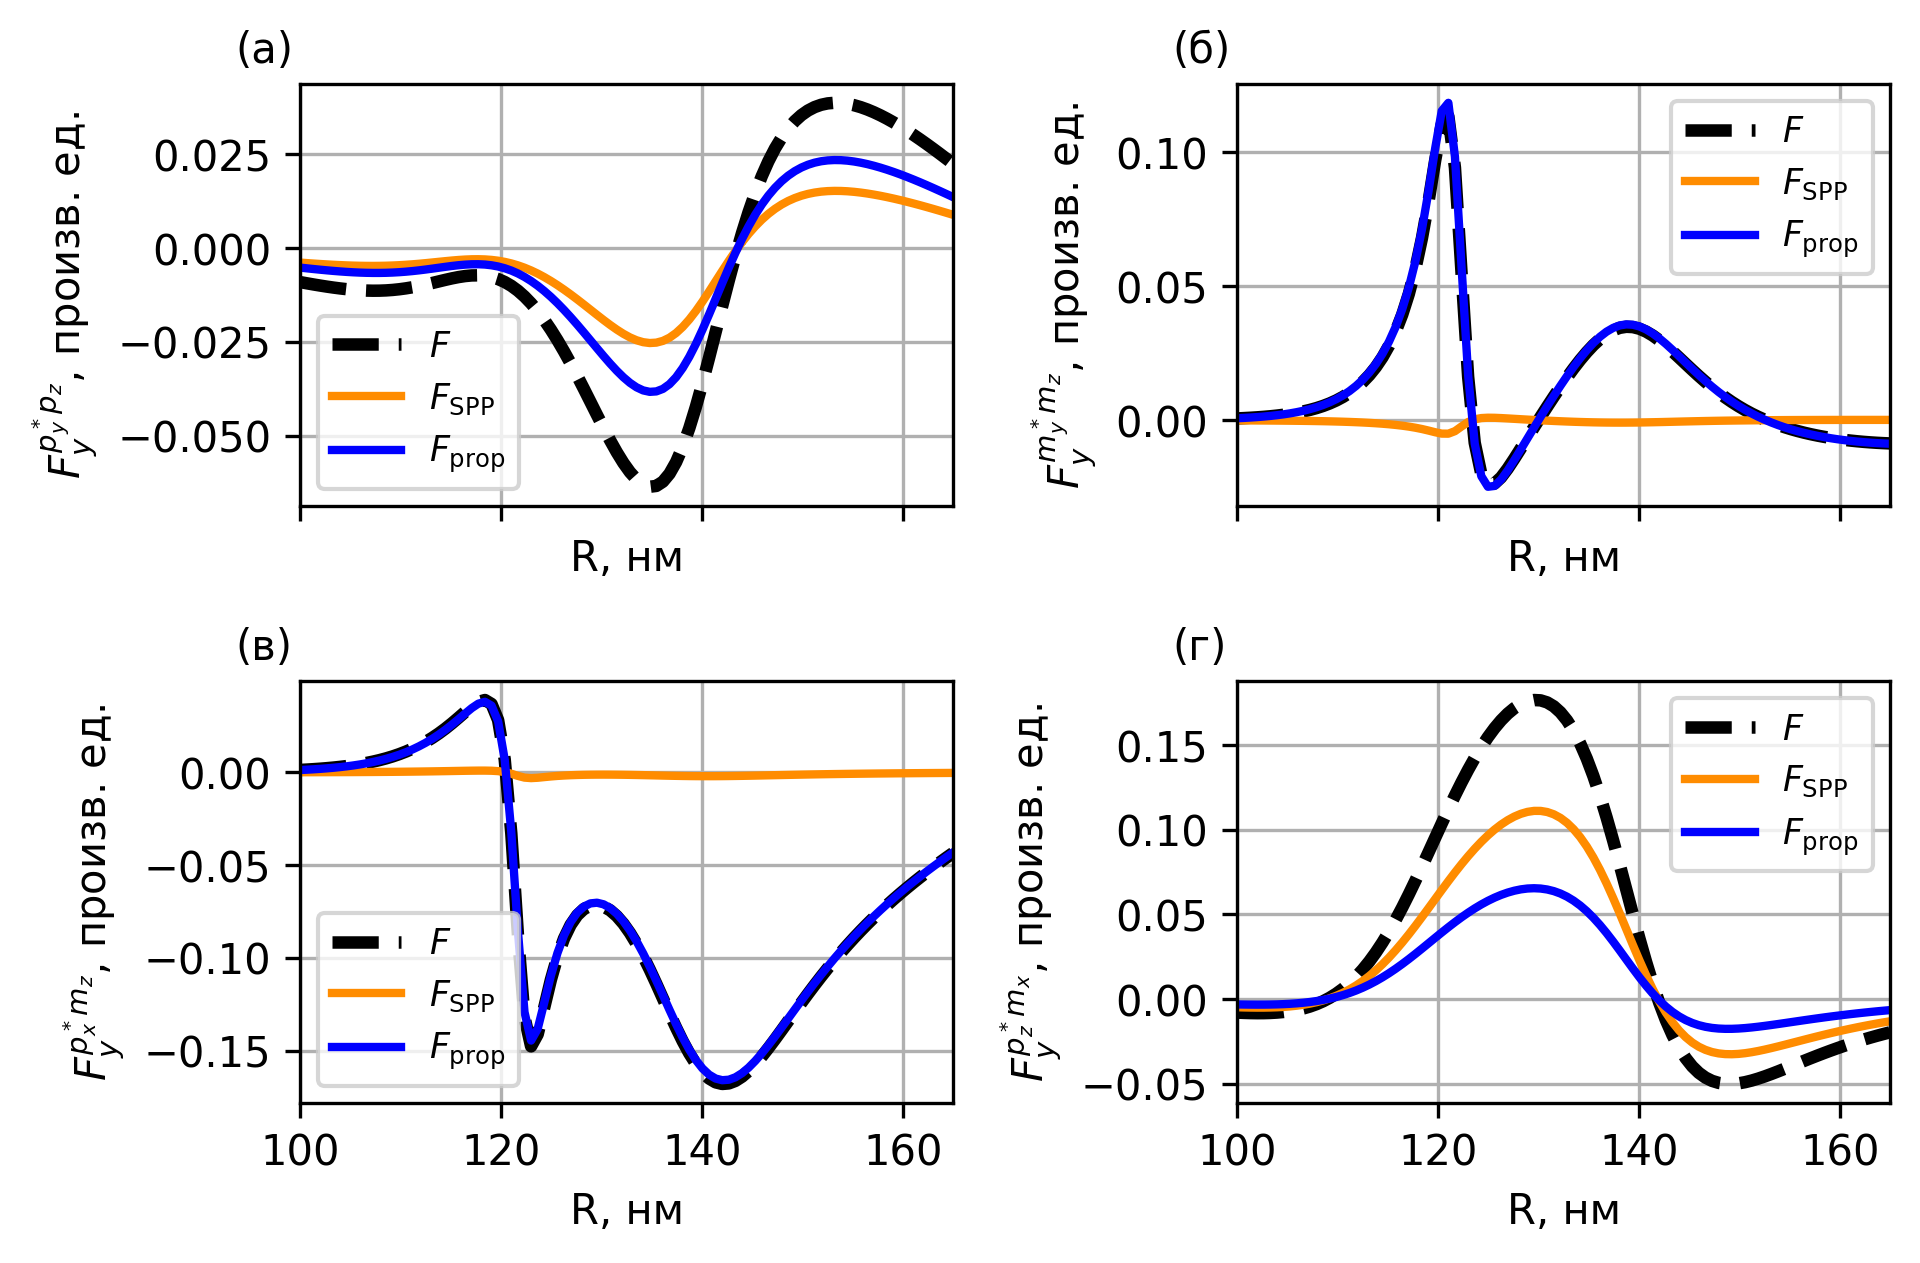

In [80]:
Ffull = [Fxe1_one, Fxm1_one, Fxpymz_one, Fxpzmy_one, Fye1_one, Fym1_one, Fypxmz_one, Fypzmx_one]
F01 = [Fxe1_01_one, Fxm1_01_one, Fxpymz_01_one, Fxpzmy_01_one, Fye1_01_one, Fym1_01_one, Fypxmz_01_one, Fypzmx_01_one]
Fspp = [Fxe1_spp_one, Fxm1_spp_one, Fxpymz_spp_one, Fxpzmy_spp_one, Fye1_spp_one, Fym1_spp_one, Fypxmz_spp_one, Fypzmx_spp_one]
Flabels =  ['F_x^{p_x^* p_z}', 'F_x^{m_x^* m_z}', 'F_x^{p_y^*m_z}', 'F_x^{p_z^*m_y}',
            'F_y^{p_y^* p_z}', 'F_y^{m_y^* m_z}', 'F_y^{p_x^*m_z}', 'F_y^{p_z^*m_x}']
plot_labels = ['(a)', '(б)', '(в)', '(г)']

def _plot_group(ax, total, spp, air, label, ind):
    ax.plot(R, total/F0, label='$F$', lw=3, ls='--', c='black')
    ax.plot(R, spp/F0, label= '$F_{\\text{SPP}}$', lw=2, c='darkorange')
    ax.plot(R, air/F0, label='$F_{\\text{prop}}$', lw=2, c='blue')
    ax.set_xlabel('R, нм')
    ax.grid(True)
    ax.text(-0.1, 1.05, plot_labels[ind], transform=ax.transAxes, fontsize=10, fontweight='normal')


for title, offset in [('F_x', 0), ('F_y', 4)]:
    fig, axs = plt.subplots(2, 2, figsize=(6.5, 4.5), dpi=300, sharex=True)
    axs = axs.flatten()
    for idx in range(offset, offset + 4):
        _plot_group(axs[idx - offset], Ffull[idx], Fspp[idx], F01[idx], Flabels[idx], idx - offset)
        axs[idx - offset].set_ylabel(f'${Flabels[idx]}$, произв. ед.', fontsize=10)
        axs[idx - offset].legend(fontsize='small')
        axs[idx - offset].set_xlim(R[0], R[-1])
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'proceeding/{title}_spp_air_components.png', dpi=300)
    plt.show()

In [99]:
from matplotlib.ticker import FixedLocator, FixedFormatter
import numpy as np
import matplotlib.pyplot as plt


Ffull = [Fxe1_one, Fxm1_one, Fxpymz_one, Fxpzmy_one,
         Fye1_one, Fym1_one, Fypxmz_one, Fypzmx_one]

F01 = [Fxe1_01_one, Fxm1_01_one, Fxpymz_01_one, Fxpzmy_01_one,
       Fye1_01_one, Fym1_01_one, Fypxmz_01_one, Fypzmx_01_one]

Fspp = [Fxe1_spp_one, Fxm1_spp_one, Fxpymz_spp_one, Fxpzmy_spp_one,
        Fye1_spp_one, Fym1_spp_one, Fypxmz_spp_one, Fypzmx_spp_one]

Flabels = ['F_x^{p_x^* p_z}', 'F_x^{m_x^* m_z}',
           'F_x^{p_y^*m_z}', 'F_x^{p_z^*m_y}',
           'F_y^{p_y^* p_z}', 'F_y^{m_y^* m_z}',
           'F_y^{p_x^*m_z}', 'F_y^{p_z^*m_x}']

plot_labels = ['(a)', '(б)', '(в)', '(г)']


def _format_axes(ax):
    Rmin, Rmax = R[0], R[-1]
    ax.set_xlim(Rmin, Rmax)
    
    n_xticks = 7
    n_yticks = 7
    x_ticks = np.linspace(Rmin, Rmax, n_xticks)
    ax.xaxis.set_major_locator(FixedLocator(x_ticks))

    x_labels = [f"{val.magnitude:.0f}" if i % 2 == 0 else ""
                for i, val in enumerate(x_ticks)]
    ax.xaxis.set_major_formatter(FixedFormatter(x_labels))


    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin*1.15, ymax*1.15)
    y_ticks = np.linspace(ymin, ymax, n_yticks)
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    y_labels = [f"{val:.2f}" if i % 2 == 0 else ""
                for i, val in enumerate(y_ticks)]
    ax.yaxis.set_major_formatter(FixedFormatter(y_labels))

    # Метки внутрь
    ax.tick_params(direction='in',
                   length=4,
                   width=1,
                   top=True,
                   right=True)


def _plot_group(ax, total, spp, air, label, ind):
    ax.plot(R, total/F0, lw=3, ls='--', c='black', label=r'$F$')
    ax.plot(R, spp/F0, lw=2, c='orange', label=r'$F_{\mathrm{SPP}}$')
    ax.plot(R, air/F0, lw=2, c='blue', label=r'$F_{\mathrm{prop}}$')

    ax.set_xlabel(r'$R$, нм')
    ax.set_ylabel(f'${label}$, произв. ед.')

    ax.text(-0.30, 1.1, plot_labels[ind],
            transform=ax.transAxes,
            fontsize=10)

    _format_axes(ax)

    leg = ax.legend(frameon=True, loc='best', fontsize='small')
    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_alpha(.75)
    leg.get_frame().set_edgecolor('none')




for title, offset in [('F_x', 0), ('F_y', 4)]:

    fig, axs = plt.subplots(2, 2,
                            figsize=(6.5, 4.5),
                            dpi=300,
                            sharex=True)

    axs = axs.flatten()

    for idx in range(offset, offset + 4):
        _plot_group(axs[idx - offset],
                    Ffull[idx],
                    Fspp[idx],
                    F01[idx],
                    Flabels[idx],
                    idx - offset)

    plt.tight_layout()
    plt.savefig(f'proceeding/fixed/{title}_spp_air_components.png', dpi=300)
    
    for ax in axs:
        ax.xaxis.label.set_visible(False)
        ax.yaxis.label.set_visible(False)

        ax.tick_params(labelbottom=False,
                       labelleft=False,
                       bottom=False,
                       left=False,
                       top=False,
                       right=False)

        leg = ax.get_legend()
        if leg:
            leg.remove()

        for txt in ax.texts:
            txt.remove()

    plt.savefig(f'proceeding/fixed/{title}_spp_air_components_clear.png',
                dpi=300)

    plt.close(fig)

/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/matplotlib/ticker.py:1780: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  self.locs = np.asarray(locs)


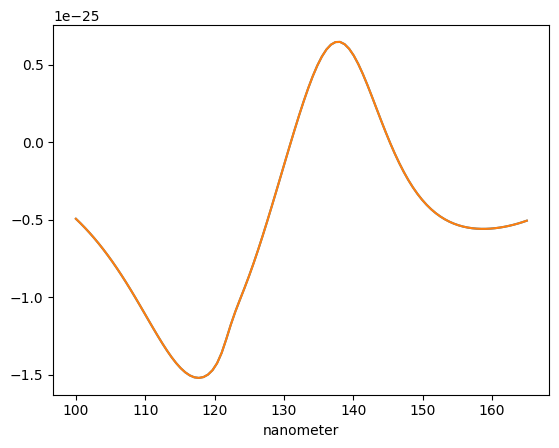

In [91]:
plt.plot(R, res1.Fxspp.magnitude)
plt.plot(R, Fxe1_spp_one.magnitude+Fxm1_spp_one.magnitude + Fxpymz_spp_one + Fxpzmy_spp_one)

Text(0.5, 0, 'R (nm)')

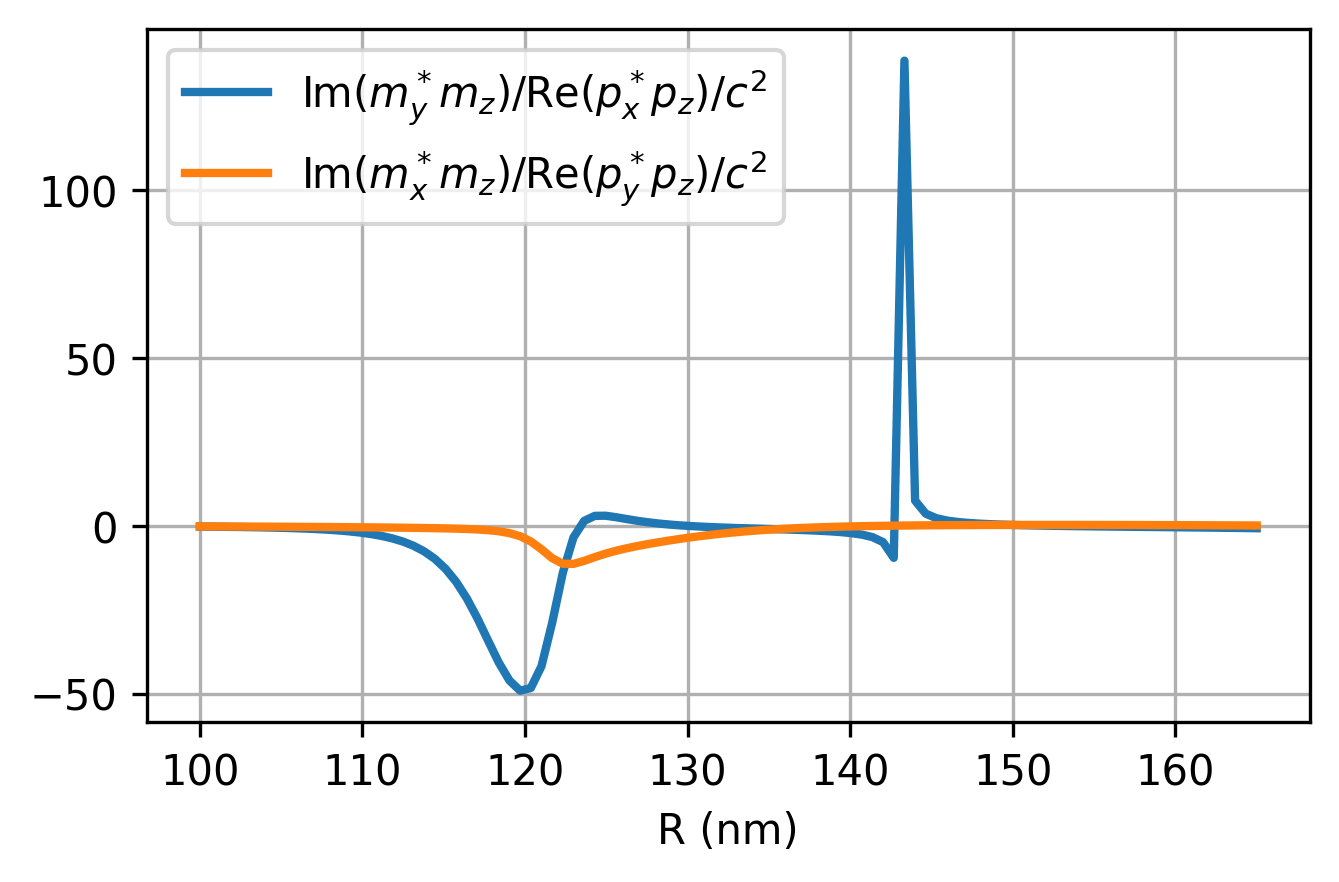

In [92]:
plt.figure(figsize=(5,3), dpi=300)
plt.plot(R, np.imag(my_one.conj()*mz_one)/np.real(px_one.conj()*pz_one*c_const**2), label='Im($m_y^* m_z$)/Re($p_x^*p_z$)/$c^2$', lw=2)

plt.plot(R, np.imag(mx_one.conj()*mz_one)/np.real(py_one.conj()*pz_one*c_const**2), label='Im($m_x^* m_z$)/Re($p_y^*p_z$)/$c^2$', lw=2)

plt.grid()
plt.legend()
plt.xlabel('R (nm)')
